# Sample Product 1

## Package

In [99]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading

In [100]:
# read file csv
df = pd.read_csv('products.csv')

# 5 baris dataframe
display(df.head())

# check info dataframe
df.info()

# check duplicated data
duplicated = df.duplicated().sum()
print(f'Duplicated Data Berjumlah: {duplicated}')

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added
0,8826d916-cdfb-41c6-81ff-91a761565a70,The Elite Cipher - PlayStation 5 Edition,Bring joy to playtime with the The Elite Ciphe...,Toys & Games,Video Games,Hasbro,12.93,NaN,0,16,2024-09-04
1,2416da6e-c212-4ddb-8d88-00160eb686b2,KitchenAid Ultra-Soft Bedding,Designed to make your home more beautiful and ...,Home & Kitchen,Bedding,KitchenAid,31.65,2.0,1,12,2024-06-02
2,eb819333-b501-4c18-8c53-c786ed62c2f9,Mobil Premium Car Care,The Mobil Premium Car Care delivers profession...,Automotive,Car Care,Mobil,42.34,1.0,1,1,2024-03-26
3,71445abc-2f0d-4ac2-8097-acb7a3823bc9,Wilson Cycling - Navy,Engineered for peak performance in any conditi...,Sports & Outdoors,Cycling,Wilson,37.73,4.5,2,1,2023-06-19
4,13d16283-160e-4c20-aebd-f9d6297e4c73,Samsung Prime Prime15,Experience cutting-edge technology with the Sa...,Electronics,Smartphones,Samsung,123.44,3.5,2,2,2023-03-07


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1000 non-null   object 
 1   product_name         1000 non-null   object 
 2   product_description  1000 non-null   object 
 3   category             1000 non-null   object 
 4   subcategory          1000 non-null   object 
 5   brand                1000 non-null   object 
 6   price                1000 non-null   float64
 7   rating_avg           452 non-null    float64
 8   review_count         1000 non-null   int64  
 9   stock_quantity       1000 non-null   int64  
 10  date_added           1000 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 86.1+ KB
Duplicated Data Berjumlah: 0


**Dataset:**

Dataset product memiliki 1000 baris data dengan 11 kolom yang terdiri dari: 

- 6 kolom kategori
- 4 kolom numerik
- 1 kolom datetime

dari semua kolom tersebut tidak memiliki duplicated data tapi memiliki missing value pada kolom 'rating_avg'. Memori yang digunakan dataset ini berjumlah +86.1 KB.

In [101]:
# deskriptif product
df.describe()

,price,rating_avg,review_count,stock_quantity
count,1000.000000,452.000000,1000.000000,1000.000000
mean,70.426930,4.048894,1.253000,16.542000
std,99.230043,1.013095,3.520708,178.069579
min,1.990000,1.000000,0.000000,1.000000
25%,17.562500,3.500000,0.000000,1.000000
50%,35.070000,4.000000,0.000000,1.000000
75%,74.332500,5.000000,1.000000,3.000000
max,886.760000,5.000000,49.000000,5000.000000


**Deskriptif Dataset:**

dari deskriptif dataset memiliki 4 column numerik:

- price 
- rating_avg
- review_count
- stock_quantity

dari 3 column price, review_count, dan stock_quantity memiliki range yang tidak seimbang antara median dengan rata-rata tiap column, 3 column tersebut ter-idikasi memiliki outlier yang ekstrim seperti:
- 75% product memiliki stock_quantity berjumalah 1 sebaliknya ada juga product yang memiliki stock_quantity hingga 5000 product
- 50% product memiliki review_count berjumlah 0 sebaliknya ada juga product dengan review_count hingga 49 review
- 75% product memiliki price memiliki harga <= 74.34 sebaliknya ada juga product dengan harga hingga 886.76

## Data Cleaning

In [102]:
# mengubah inconsistent dtypes 
df['date_added'] = pd.to_datetime(df['date_added'],format="%Y-%m-%d")
print(df['date_added'].dtypes)

datetime64[ns]


In [103]:
# check persentase missing value
missing = df['rating_avg'].isnull().sum()/len(df)*100
print(f'Persentase Missing: {missing.round(2)}%')
df.sample(n=7 ,random_state=11)

Persentase Missing: 54.8%


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added
25,453c2ed5-172f-4d33-87de-0dce637ee201,Corkcicle Premium Furniture,Designed to make your home more beautiful and ...,Home & Kitchen,Furniture,Corkcicle,176.92,NaN,0,1,2023-10-15
464,34c9ff5f-00f5-4f95-b1b7-2686317131bc,Nike Premium Accessorie,The Nike Premium Accessorie combines style wit...,Clothing & Accessories,Accessories,Nike,10.43,4.5,2,1,2025-12-31
372,fca9701c-7e41-4782-a1cb-5b46e500507d,Adidas Gold-Plated Jewelry,The Adidas Gold-Plated Jewelry combines style ...,Clothing & Accessories,Jewelry,Adidas,82.36,NaN,0,2,2023-08-07
730,5e875953-b164-41c5-91ad-a71f35ae5c8a,Apple Wireless Accessorie,"Engineered for excellence, the Apple Wireless ...",Electronics,Accessories,Apple,208.37,NaN,0,1,2025-10-29
757,50478039-ee43-4ae5-a86f-81bb8b3ac845,MSR Ultralight Camping Gear,Take your performance to the next level with t...,Sports & Outdoors,Camping Gear,MSR,71.88,5.0,2,9,2026-01-29
357,73a75a44-cd7c-4fc9-b3ff-6378dee9672f,The smart Statistics Handbook,Discover the story behind The smart Statistics...,Books,Educational,Penguin Books,9.00,NaN,0,1,2024-11-16
565,53a21506-3f1d-4aff-895f-2208f4ae3684,Le Creuset Core Appliance,Elevate your everyday living with the Le Creus...,Home & Kitchen,Appliances,Le Creuset,95.75,NaN,0,1,2024-11-16


In [104]:
# seleksi dataframe guna check korelasi missing value
is_missing_rating = df['rating_avg'].isnull()
is_review_count_zero = df['review_count'] == 0

corr_r, pval_p = stats.pearsonr(is_missing_rating, is_review_count_zero)

print(f"Correlation: {corr_r}, P-value: {pval_p}")

Correlation: 1.0, P-value: 0.0


In [105]:
# fillna missing value dengan 0
df['rating_avg'] = df['rating_avg'].fillna(0)

# column baru untuk tanda
df['is_review'] = (df['review_count']>0).astype(int)
persentase_review = (df['is_review']==1).sum()/len(df)*100
print(f'Persentase Product Review: {persentase_review.round(2)}%')
df.sample(n=7 ,random_state=11)

Persentase Product Review: 45.2%


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_review
25,453c2ed5-172f-4d33-87de-0dce637ee201,Corkcicle Premium Furniture,Designed to make your home more beautiful and ...,Home & Kitchen,Furniture,Corkcicle,176.92,0.0,0,1,2023-10-15,0
464,34c9ff5f-00f5-4f95-b1b7-2686317131bc,Nike Premium Accessorie,The Nike Premium Accessorie combines style wit...,Clothing & Accessories,Accessories,Nike,10.43,4.5,2,1,2025-12-31,1
372,fca9701c-7e41-4782-a1cb-5b46e500507d,Adidas Gold-Plated Jewelry,The Adidas Gold-Plated Jewelry combines style ...,Clothing & Accessories,Jewelry,Adidas,82.36,0.0,0,2,2023-08-07,0
730,5e875953-b164-41c5-91ad-a71f35ae5c8a,Apple Wireless Accessorie,"Engineered for excellence, the Apple Wireless ...",Electronics,Accessories,Apple,208.37,0.0,0,1,2025-10-29,0
757,50478039-ee43-4ae5-a86f-81bb8b3ac845,MSR Ultralight Camping Gear,Take your performance to the next level with t...,Sports & Outdoors,Camping Gear,MSR,71.88,5.0,2,9,2026-01-29,1
357,73a75a44-cd7c-4fc9-b3ff-6378dee9672f,The smart Statistics Handbook,Discover the story behind The smart Statistics...,Books,Educational,Penguin Books,9.00,0.0,0,1,2024-11-16,0
565,53a21506-3f1d-4aff-895f-2208f4ae3684,Le Creuset Core Appliance,Elevate your everyday living with the Le Creus...,Home & Kitchen,Appliances,Le Creuset,95.75,0.0,0,1,2024-11-16,0


**Data Cleaning:**

pada bagian data cleaning melakukan:
- inconsistent dtype to consisstent dtype (date_add)
- check missing value (rating_avg)
- memberi tanda dengan column baru (is_review)

pada bagian ini sukses melakukan 3 tahapan tersebut, pada tahapan check missing value menemukan missning value berjenis Missing at Random (MAR), dengan perssentase 54.8% ini tergolong krusial, terjadinya missing value pada rating_avg dikarenakan review_count berjumlah 0. maka dari itu dilakukan impute dan memberi tanda dengan column baru 

## Exploration Data Analysist

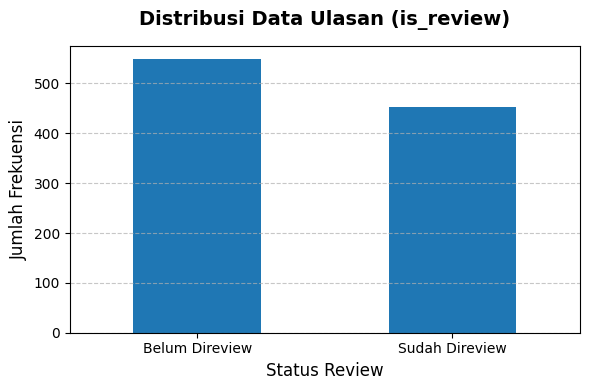

In [106]:
# 1. Hitung distribusi datanya terlebih dahulu
# Ini akan menghasilkan data text/kategori beserta jumlah frekuensinya
review_counts = df['is_review'].value_counts()

# 2. Membuat plot/grafik
plt.figure(figsize=(6, 4)) # Menentukan ukuran canvas grafik

# Membuat bar chart dengan warna kustom (opsional)
review_counts.plot(kind='bar')

# 3. Kustomisasi tampilan agar informatif dan rapi
plt.title('Distribusi Data Ulasan (is_review)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status Review', fontsize=12)
plt.ylabel('Jumlah Frekuensi', fontsize=12)

# Mengatur label sumbu X agar tidak miring (rotation=0) dan lebih mudah dibaca
# Sesuaikan label di bawah ini dengan isi data asli Anda (misal: 0 dan 1 atau True dan False)
plt.xticks(ticks=range(len(review_counts)), labels=['Belum Direview', 'Sudah Direview'], rotation=0)

# Menambahkan garis bantu horizontal (grid) agar nilainya lebih mudah dibaca secara visual
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mengatur layout agar teks tidak terpotong
plt.tight_layout()

# 4. Tampilkan grafik ke layar
plt.show()

**Temuan:**

dalam tahap ini, melakukan exploration terhadap column 'is_review', terdapat 2 kategori product:
- belum review(+500)
- sudah review(+400)

dalam distribusi column 'is_review' telihat perbedaan jumlah product terhadap 2 kategori tersebut. lebih dari sebagian product belum direview,  jika chart tersbebut sebagai aktifitas jual beli  ini menandakan kurangnya minat konsumen terhadap sebagian product. jika ini dibiarkan akan menjadi bom waktu dikemudian hari terkhusus pada gudang penyimpanan product.  

### Top 10 product berdasarkan review_count

In [107]:
is_review = df[df['is_review']==1]
top_product = is_review.sort_values(by= 'review_count', ascending=False).head(10)
top_product.reset_index(drop=True,inplace=True)
top_product.index = top_product.index+1
display(top_product)


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_review
1,6e9b539a-77ad-4307-acb5-f558f8b5cc6f,Apple Accessorie Stand,Experience cutting-edge technology with the Ap...,Electronics,Accessories,Apple,70.02,4.1,49,1,2023-03-29,1
2,dbe68f3f-99a8-4ef2-a103-908a6fca244d,Wilson Fitness Equipment Pro,Engineered for peak performance in any conditi...,Sports & Outdoors,Fitness Equipment,Wilson,49.13,3.9,37,4,2024-10-31,1
3,eaaf2b74-b09a-4bf5-b0b2-09021044cab8,Instant Pot Microfiber Kitchenware,Transform your home with the Instant Pot Micro...,Home & Kitchen,Kitchenware,Instant Pot,94.87,4.2,28,2,2025-06-20,1
4,c1ab2206-9b50-4aaa-9446-f322d0976ea6,The Data Structures: A Comprehensive Guide,Discover the story behind The Data Structures:...,Books,Non-Fiction,Simon & Schuster,19.97,3.9,28,5000,2023-03-03,1
5,d3701c21-709a-4090-bab2-020261ce8a92,Cuisinart Smart Appliance,The Cuisinart Smart Appliance brings both styl...,Home & Kitchen,Appliances,Cuisinart,44.48,4.2,27,5,2023-08-21,1
6,25a6c99c-d63c-4697-91ef-744b7879d605,Post-it Premium Stationery Set,Stay organized and productive with the Post-it...,Office Products,Stationery,Post-it,45.91,4.1,26,1,2025-04-25,1
7,5d07bcd4-3670-4a0d-91f6-e36d7d335597,Adidas Sterling Silver Jewelry,Designed for those who refuse to compromise on...,Clothing & Accessories,Jewelry,Adidas,27.22,3.9,23,35,2024-12-27,1
8,88f38eae-9124-4557-a285-248fc1cad30c,Nestle Pantry Staple Multipack,Savor the rich flavors of the Nestle Pantry St...,Grocery & Gourmet,Pantry Staples,Nestle,7.74,4.1,22,8,2023-04-09,1
9,c2e39751-db17-424f-8d71-61ec7ecad424,Neutrogena Bath & Body Lotion,Nourish and pamper yourself with the Neutrogen...,Beauty & Personal Care,Bath & Body,Neutrogena,33.80,4.3,22,1,2024-08-29,1
10,58fd8edb-60ef-4856-bf1f-644ffc133d12,Wilson Book19 Fitness Equipment,Engineered for peak performance in any conditi...,Sports & Outdoors,Fitness Equipment,Wilson,107.09,4.3,21,55,2023-11-22,1


**Temuan:**

dalam 10 top product bedasarkan review_count terdapat macam-macam kondisi product seperti:
- krisis stock product
- anomaly stock product
- ideal stock product

 7/10 product memiliki krisis product seperti stock_quantity -10 ini perlu di-intercept seperti restock darurat dan alihkan/rekomendasikan ke-brand lain jika permintaan melebihi stock yang ada. dan juga anomaly stock product hingga 5000 stock product, guna tidak terjadinya bom waktu pada gudang, treatment untuk product misal paket gratis untuk pembelian laptop atau barang relevan dengan tema buku. 



### Top 1 product berdasarkan review_count

In [108]:
accessories = is_review[is_review['subcategory']=='Accessories']
accessories.loc[df['product_description'].str.find('Accessorie Stand') != -1]
# df.loc[df['product_description'].str.find('Accessorie Stand') != -1]
# df['description_length'] = df['product_description'].astype(str).str.len()
# tanggal_target = pd.to_datetime('2026-05-27')
# df['product_age_days'] = (tanggal_target - df['date_added']).dt.days
# # Membuat kategori berdasarkan jumlah hari
# bins = [-1, 90, 180, 365, float('inf')]
# labels = ['0-3 Bulan', '3-6 Bulan', '6-12 Bulan', 'Lebih dari 1 Tahun']
# df['age_category'] = pd.cut(df['product_age_days'], bins=bins, labels=labels)


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_review
34,6e9b539a-77ad-4307-acb5-f558f8b5cc6f,Apple Accessorie Stand,Experience cutting-edge technology with the Ap...,Electronics,Accessories,Apple,70.02,4.1,49,1,2023-03-29,1
718,1e7c79d1-0a00-4d37-b3e1-2f6262900884,Samsung Accessorie Stand,Upgrade your setup with the powerful Samsung A...,Electronics,Accessories,Samsung,90.86,3.0,1,2,2025-09-26,1
957,4b9c83ae-69fe-4826-ac62-bae53913ea33,Apple Accessorie Stand,"Engineered for excellence, the Apple Accessori...",Electronics,Accessories,Apple,286.89,3.8,5,8,2023-11-03,1


**Temuan:**

product dengan accsessoie stand dengan brand apple menjadi top 1 product yang ter-indikasi kekurangan stock jika restock darurat tidak dapat dilaksanakan dengan baik maka memberi rekomendasi product serupa merupakan cara terbaik untuk sementara. productnya seperti dataframe diatas.


#### Kenapa bisa top 1 product 

In [109]:
accessorie_stand = df.loc[df['product_description'].str.find('Accessorie Stand') != -1].copy()
print(f'jumlah product dengan nama Accessorie Stand : {len(accessorie_stand)}')
accessorie_stand

jumlah product dengan nama Accessorie Stand : 5


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_review
34,6e9b539a-77ad-4307-acb5-f558f8b5cc6f,Apple Accessorie Stand,Experience cutting-edge technology with the Ap...,Electronics,Accessories,Apple,70.02,4.1,49,1,2023-03-29,1
512,9bbf3ec0-bb7a-45a8-8500-1b2c03596f4d,Microsoft Accessorie Stand,"Engineered for excellence, the Microsoft Acces...",Electronics,Accessories,Microsoft,55.41,0.0,0,1,2023-01-19,0
718,1e7c79d1-0a00-4d37-b3e1-2f6262900884,Samsung Accessorie Stand,Upgrade your setup with the powerful Samsung A...,Electronics,Accessories,Samsung,90.86,3.0,1,2,2025-09-26,1
874,ddea521a-f6e7-4379-9a0f-841f828b1473,Samsung Accessorie Stand,The Samsung Accessorie Stand delivers exceptio...,Electronics,Accessories,Samsung,335.15,0.0,0,1,2024-05-29,0
957,4b9c83ae-69fe-4826-ac62-bae53913ea33,Apple Accessorie Stand,"Engineered for excellence, the Apple Accessori...",Electronics,Accessories,Apple,286.89,3.8,5,8,2023-11-03,1


In [110]:
accessorie_stand['description_length'] = accessorie_stand['product_description'].astype(str).str.len()
tanggal_target = pd.to_datetime('2026-05-27')
accessorie_stand['product_age_days'] = (tanggal_target - accessorie_stand['date_added']).dt.days
# Membuat kategori berdasarkan jumlah hari
bins = [-1, 90, 180, 365, float('inf')]
labels = ['0-3 Bulan', '3-6 Bulan', '6-12 Bulan', 'Lebih dari 1 Tahun']
accessorie_stand['age_category'] = pd.cut(accessorie_stand['product_age_days'], bins=bins, labels=labels)
freq_brand = accessorie_stand['brand'].value_counts(normalize = True)
freq_brand
accessorie_stand['freq_brand'] = accessorie_stand['brand'].map(freq_brand)
accessorie_stand



,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_review,description_length,product_age_days,age_category,freq_brand
34,6e9b539a-77ad-4307-acb5-f558f8b5cc6f,Apple Accessorie Stand,Experience cutting-edge technology with the Ap...,Electronics,Accessories,Apple,70.02,4.1,49,1,2023-03-29,1,658,1155,Lebih dari 1 Tahun,0.4
512,9bbf3ec0-bb7a-45a8-8500-1b2c03596f4d,Microsoft Accessorie Stand,"Engineered for excellence, the Microsoft Acces...",Electronics,Accessories,Microsoft,55.41,0.0,0,1,2023-01-19,0,560,1224,Lebih dari 1 Tahun,0.2
718,1e7c79d1-0a00-4d37-b3e1-2f6262900884,Samsung Accessorie Stand,Upgrade your setup with the powerful Samsung A...,Electronics,Accessories,Samsung,90.86,3.0,1,2,2025-09-26,1,720,243,6-12 Bulan,0.4
874,ddea521a-f6e7-4379-9a0f-841f828b1473,Samsung Accessorie Stand,The Samsung Accessorie Stand delivers exceptio...,Electronics,Accessories,Samsung,335.15,0.0,0,1,2024-05-29,0,502,728,Lebih dari 1 Tahun,0.4
957,4b9c83ae-69fe-4826-ac62-bae53913ea33,Apple Accessorie Stand,"Engineered for excellence, the Apple Accessori...",Electronics,Accessories,Apple,286.89,3.8,5,8,2023-11-03,1,664,936,Lebih dari 1 Tahun,0.4


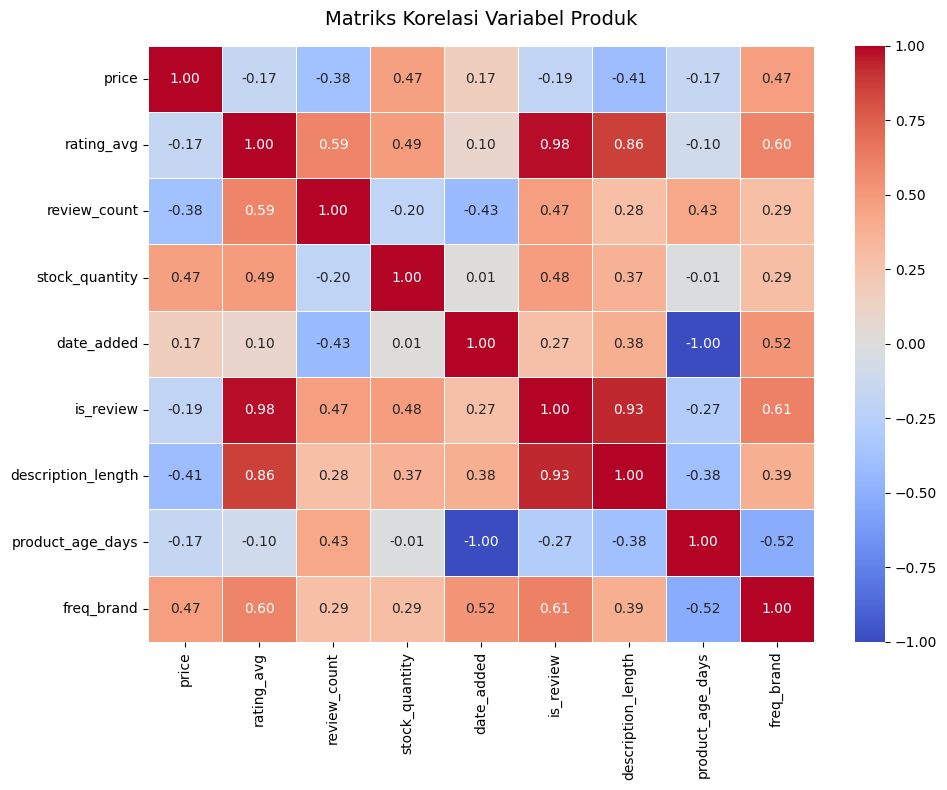

In [111]:
# 1. Pilih kolom-kolom numerik (menghindari tipe 'object')
kolom_numerik = accessorie_stand.select_dtypes(exclude=['object'])

# TAMBAHKAN KODE INI: Drop kolom 'age_category' jika ada di dalam data
if 'age_category' in kolom_numerik.columns:
    kolom_numerik = kolom_numerik.drop(columns=['age_category'])

# 2. Hitung matriks korelasi menggunakan kolom yang sudah bersih
matriks_korelasi = kolom_numerik.corr()

# 3. Atur ukuran kanvas grafik agar nyaman dibaca
plt.figure(figsize=(10, 8))

# 4. Gambar heatmap
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 5. Tambahkan judul dan rapikan layout
plt.title('Matriks Korelasi Variabel Produk', fontsize=14, pad=15)
plt.tight_layout()

# 6. Tampilkan grafik
plt.show()

**Temuan:**

kenapa product dengan nama accessorie stand brand apple bisa menjadi top 1 product padahal product nama accessorie stand lain juga ada. hal yang mempengaruhi dapat dilihat pada chart heatmap. jika review_count diaanggap jumlah pembelian yang mempengaruhi ialah:
- rating_avg(0.59)
- is_review(0.47)
- product_age_days(0.43)
- freq_brand(0.29)

dapat disimpulkan pembelian terjadi dipengaruhi rating_avg jika product tidak memiliki rating kecil kemungkinan akan terjadinya jual beli dengan costumer. jika tidak terjadinya restock darurat maka pergunakanlah korelasi tersebut untuk rekmendasi product .



In [112]:
a

NameError: name 'a' is not defined

## Feature Engineering

# Package

In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns',None)

In [ ]:
def check_data(df):
    ''' 
        fungsi ini menampilkan info dataframe
    '''
    duplicatedV = df.duplicated().sum()
    print(f'Duplicated Value: {duplicatedV}\n')
    df.info()
    return df.sample(n=7, random_state=11)
    

## Product

In [ ]:
# read file csv
product_table = pd.read_csv('products.csv')

# check kualitas data
check_data(product_table)

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1000 non-null   object 
 1   product_name         1000 non-null   object 
 2   product_description  1000 non-null   object 
 3   category             1000 non-null   object 
 4   subcategory          1000 non-null   object 
 5   brand                1000 non-null   object 
 6   price                1000 non-null   float64
 7   rating_avg           452 non-null    float64
 8   review_count         1000 non-null   int64  
 9   stock_quantity       1000 non-null   int64  
 10  date_added           1000 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 86.1+ KB


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added
25,453c2ed5-172f-4d33-87de-0dce637ee201,Corkcicle Premium Furniture,Designed to make your home more beautiful and ...,Home & Kitchen,Furniture,Corkcicle,176.92,NaN,0,1,2023-10-15
464,34c9ff5f-00f5-4f95-b1b7-2686317131bc,Nike Premium Accessorie,The Nike Premium Accessorie combines style wit...,Clothing & Accessories,Accessories,Nike,10.43,4.5,2,1,2025-12-31
372,fca9701c-7e41-4782-a1cb-5b46e500507d,Adidas Gold-Plated Jewelry,The Adidas Gold-Plated Jewelry combines style ...,Clothing & Accessories,Jewelry,Adidas,82.36,NaN,0,2,2023-08-07
730,5e875953-b164-41c5-91ad-a71f35ae5c8a,Apple Wireless Accessorie,"Engineered for excellence, the Apple Wireless ...",Electronics,Accessories,Apple,208.37,NaN,0,1,2025-10-29
757,50478039-ee43-4ae5-a86f-81bb8b3ac845,MSR Ultralight Camping Gear,Take your performance to the next level with t...,Sports & Outdoors,Camping Gear,MSR,71.88,5.0,2,9,2026-01-29
357,73a75a44-cd7c-4fc9-b3ff-6378dee9672f,The smart Statistics Handbook,Discover the story behind The smart Statistics...,Books,Educational,Penguin Books,9.00,NaN,0,1,2024-11-16
565,53a21506-3f1d-4aff-895f-2208f4ae3684,Le Creuset Core Appliance,Elevate your everyday living with the Le Creus...,Home & Kitchen,Appliances,Le Creuset,95.75,NaN,0,1,2024-11-16


In [ ]:
product_table.duplicated(subset='product_id').sum()

0

**Temuan Data:**

- tidak memiliki duplicated
- memiliki inconsissten dtype pada column date_added
- memiliki missing value column rating_avg 

### Inconsistent Dtype

In [ ]:
# Mengubah dtype colomn date_added
product_table['date_added'] = pd.to_datetime(product_table['date_added'],yearfirst=True)
product_table.date_added.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: date_added
Non-Null Count  Dtype         
--------------  -----         
1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.9 KB


### Missing Value

#### Apa yang Mempengaruhi Missing Value

In [ ]:
# Check jumlah missing value
missingV = product_table.rating_avg.isna().sum()
jumlahV = len(product_table['rating_avg'])
print(f'Missing Value Berjumlah: {missingV} atau {(missingV*100)/jumlahV}%')

Missing Value Berjumlah: 548 atau 54.8%


In [ ]:
# Validasi missing value
tanpa_review= product_table[product_table['review_count']==0]
print(f'Jumlah Review Product: {len(tanpa_review)}')
tanpa_review.sample(n=7,random_state=11)

Jumlah Review Product: 548


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added
499,72af798d-dd65-4dfe-b807-d84757d3e847,A Superior Spectrum: Building Real-World Solut...,A Superior Spectrum: Building Real-World Solut...,Books,Comics,Hachette,12.35,NaN,0,5,2025-04-27
811,478897ba-ae46-48cf-b2bb-82c4f374cb16,PepsiCo Sweet Snack,The PepsiCo Sweet Snack brings premium quality...,Grocery & Gourmet,Snacks,PepsiCo,19.79,NaN,0,4,2024-04-18
555,319626f2-4728-4a27-be50-c20681a43c6c,Yeti Series6 Cycling,Take your performance to the next level with t...,Sports & Outdoors,Cycling,Yeti,31.32,NaN,0,1,2023-08-10
90,580a7cd8-07fa-4ae4-9eeb-313942ebb8e4,KitchenAid Lighting - Charcoal,Transform your home with the KitchenAid Lighti...,Home & Kitchen,Lighting,KitchenAid,56.11,NaN,0,1,2025-10-29
809,db090e5d-82e1-4bfe-83ba-09e2ee97e409,Samsung Core Smartwatch,The Samsung Core Smartwatch delivers exception...,Electronics,Wearables,Samsung,228.41,NaN,0,1,2026-04-15
790,d04b581e-dc6b-40e3-8e1e-0b29551b7950,Mattel Pro Deluxe Zoe,The Mattel Pro Deluxe Zoe sparks creativity an...,Toys & Games,Action Figures,Mattel,34.21,NaN,0,12,2023-09-03
774,004eb82c-1643-4850-9738-fd2e2c81d645,L'Oreal Velvet Eau de Toilette,The L'Oreal Velvet Eau de Toilette is your new...,Beauty & Personal Care,Fragrance,L'Oreal,30.62,NaN,0,1,2025-11-26


In [ ]:
tanpa_review1 = tanpa_review.review_count.count()
# print(type(tanpa_review1))
# print(type(missingV))
pd.DataFrame({
    'Missing Value pada rating_avg':missingV,
    'Riview_count adalah 0':tanpa_review1
},index=['Jumlah'])


,Missing Value pada rating_avg,Riview_count adalah 0
Jumlah,548,548


**Temuan Missing Value:**


dari temuan, missing value pada rating_avg sangat krusial dengan nilai 54.8%.  terjadinya kondisi missing value pada ranting_avg terjadi dikarnakan tidak adanya review atau review_count terhadap product tersebut, kemungkinan:

- product tidak ter-expose
- product kurang diminati
- dan tidak adanya review user setelah pembelian

jika dibiarkan tanpa intercept product minim akan menarik perhatian user dan akan menjadi sampah digudang dan pada product_table saya me-intercept missing value tersebut dengan impute berdasarkan distribusi rating_avg per subcategori'

#### Bagaimana Menyukapi Missing Value

In [ ]:
product_table[['subcategory', 'rating_avg']].pivot_table(
    index='subcategory',
    aggfunc={
        'rating_avg':[
        ('Missing Value rating_avg',lambda x:x.isna().sum()),
        ('Total ',lambda x:x.isna().sum()+x.count()),
        ('Rating_avg','count')
        ]
    }
)

rating_avg                  
                   Missing Value rating_avg Rating_avg Total 
subcategory                                                  
Accessories                              22         23     45
Action Figures                           13         10     23
Appliances                                6          8     14
Bags                                      6          7     13
Bath & Body                               7          6     13
Bedding                                  23          4     27
Beverages                                 6          3      9
Board Games                               5         10     15
Cameras                                  11         10     21
Camping Gear                              8         12     20
Car Accessories                           5          4      9
Car Care                                  0          6      6
Children's Books                         13         10     23
Comics                                   12          5     17
Cycling                                   8         10     18
Educational                              24          4     28
Educational Toys                         13          3     16
Electronics                               0          6      6
Fiction                                  14         13     27
Fitness Equipment                         8         10     18
Fluids                                    5          2      7
Footwear                                 17         14     31
Fragrance                                13          8     21
Furniture                                18         11     29
Gourmet Foods                             5          0      5
Haircare                                 13          6     19
Headphones                               16         16     32
Home Decor                               10         11     21
Jewelry                                  11          5     16
Kitchenware                              14         16     30
Laptops                                  14         12     26
Lighting                                 13          8     21
Makeup                                    5          6     11
Menswear                                 22         24     46
Non-Fiction                              22         15     37
Office Furniture                          3          5      8
Organic Foods                             5          4      9
Organization                              1          5      6
Outdoor Recreation                       12         12     24
Pantry Staples                            9          5     14
Printers                                  5          3      8
Puzzles                                   6          7     13
Skincare                                  6          8     14
Smartphones                              30         15     45
Snacks                                    7         12     19
Stationery                                1          6      7
Supplies                                  1          4      5
Tablets                                  13          4     17
Team Sports                               5          9     14
Tools & Equipment                         3          8     11
Video Games                               6          5     11
Wearables                                12         10     22
Womenswear                               21         12     33

In [ ]:
# Langkah 1: Hitung nilai cadangan (global) jika ada sub-kategori yang kosong total
global_median = product_table['rating_avg'].median()

# Langkah 2: Ambil semua daftar sub-kategori unik
daftar_subcategory = product_table['subcategory'].unique()

# Langkah 3: Lakukan perulangan untuk setiap sub-kategori
for sub in daftar_subcategory:
    
    # a. Ambil subset data rating untuk sub-kategori yang sedang diproses
    #    .dropna() digunakan agar data kosong tidak ikut dihitung skew/mean/median
    data_rating = product_table.loc[product_table['subcategory'] == sub, 'rating_avg'].dropna()
    
    # KASUS KHUSUS: Jika sub-kategori kosong total (seperti Gourmet Foods)
    if len(data_rating) == 0:
        nilai_pengisi = global_median
        
    else:
        # b. Hitung nilai skewness data rating yang ada
        skew_val = data_rating.skew()
        
        # c. Tentukan nilai pengisi berdasarkan aturan skewness
        # pd.isna(skew_val) menjaga jika data terisi terlalu sedikit sehingga skew tidak bisa dihitung
        if np.isnan(skew_val) or abs(skew_val) <= 0.5:
            nilai_pengisi = data_rating.mean()    # Distribusi Normal -> gunakan Mean
        else:
            nilai_pengisi = data_rating.median()  # Distribusi Skewed -> gunakan Median
            
    # d. IMPUTASI: Isi data yang kosong (NaN) khusus untuk sub-kategori ini di tabel asli
    # Kondisi kiri: mencari baris sub-kategori saat ini DAN kolom 'rating_avg' yang kosong
    kondisi_kosong = (product_table['subcategory'] == sub) & (product_table['rating_avg'].isna())
    product_table.loc[kondisi_kosong, 'rating_avg'] = nilai_pengisi

# Langkah 4: Bulatkan hasil akhir agar rapi (1 angka di belakang koma)
product_table['rating_avg'] = product_table['rating_avg'].round(1)


In [ ]:

# Langkah 5 memberi tanda impute menggunakan column baru
daftar = []
for i in product_table['review_count']:
    if i == 0:
        daftar.append(int(1))
    else:
        daftar.append(int(0))

product_table['is_impute'] = daftar

In [ ]:
check_data(product_table)

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   product_id           1000 non-null   object        
 1   product_name         1000 non-null   object        
 2   product_description  1000 non-null   object        
 3   category             1000 non-null   object        
 4   subcategory          1000 non-null   object        
 5   brand                1000 non-null   object        
 6   price                1000 non-null   float64       
 7   rating_avg           1000 non-null   float64       
 8   review_count         1000 non-null   int64         
 9   stock_quantity       1000 non-null   int64         
 10  date_added           1000 non-null   datetime64[ns]
 11  is_impute            1000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 93

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_impute
25,453c2ed5-172f-4d33-87de-0dce637ee201,Corkcicle Premium Furniture,Designed to make your home more beautiful and ...,Home & Kitchen,Furniture,Corkcicle,176.92,4.0,0,1,2023-10-15,1
464,34c9ff5f-00f5-4f95-b1b7-2686317131bc,Nike Premium Accessorie,The Nike Premium Accessorie combines style wit...,Clothing & Accessories,Accessories,Nike,10.43,4.5,2,1,2025-12-31,0
372,fca9701c-7e41-4782-a1cb-5b46e500507d,Adidas Gold-Plated Jewelry,The Adidas Gold-Plated Jewelry combines style ...,Clothing & Accessories,Jewelry,Adidas,82.36,3.1,0,2,2023-08-07,1
730,5e875953-b164-41c5-91ad-a71f35ae5c8a,Apple Wireless Accessorie,"Engineered for excellence, the Apple Wireless ...",Electronics,Accessories,Apple,208.37,4.0,0,1,2025-10-29,1
757,50478039-ee43-4ae5-a86f-81bb8b3ac845,MSR Ultralight Camping Gear,Take your performance to the next level with t...,Sports & Outdoors,Camping Gear,MSR,71.88,5.0,2,9,2026-01-29,0
357,73a75a44-cd7c-4fc9-b3ff-6378dee9672f,The smart Statistics Handbook,Discover the story behind The smart Statistics...,Books,Educational,Penguin Books,9.00,4.2,0,1,2024-11-16,1
565,53a21506-3f1d-4aff-895f-2208f4ae3684,Le Creuset Core Appliance,Elevate your everyday living with the Le Creus...,Home & Kitchen,Appliances,Le Creuset,95.75,4.1,0,1,2024-11-16,1


## Exploration Data Analysist

In [ ]:
product_table.describe().round(2)

,price,rating_avg,review_count,stock_quantity,date_added,is_impute
count,1000.00,1000.00,1000.00,1000.00,1000,1000.00
mean,70.43,4.21,1.25,16.54,2024-09-06 17:15:21.600000,0.55
min,1.99,1.00,0.00,1.00,2023-01-03 00:00:00,0.00
25%,17.56,4.00,0.00,1.00,2023-10-25 00:00:00,0.00
50%,35.07,4.20,0.00,1.00,2024-09-06 12:00:00,1.00
75%,74.33,5.00,1.00,3.00,2025-07-16 06:00:00,1.00
max,886.76,5.00,49.00,5000.00,2026-05-27 00:00:00,1.00
std,99.23,0.80,3.52,178.07,NaN,0.50


**Temuan:**

 semua product memiliki outlier

 terjadi karena mayoritas produk di dataset ini adalah barang-barang standar (harga murah, stok sedikit, dan sepi ulasan). Namun, ada segelintir produk khusus atau produk viral yang harganya sangat mahal (886.76), ditimbun sangat banyak (5000 unit), atau sangat sering diulas (49 ulasan), sehingga nilainya melompat jauh meninggalkan data produk lainnya

 untuk mengatasi outlier akan di intercept melakukan category menggunakan percentile dari distribusi harga berdasarkan:
 - murah (0% hingga 30%)
 - menengah (30% hingga 60%)
 - mahal (60% hingga 90%)
 - dan sangat mahal (90% hingga 100%)

 kelebihan:
 - outlier dapat di- intercept
 - analisis product menjadi lebih objectif

 kekurangan:
 - sensitif batas angka


In [ ]:
# Hitung nilai harga pada titik persentase 30%, 60%, dan 90%
pembatas_harga_baru = product_table['price'].quantile([0.33, 0.66,0.90,1.0])

print("=== Batas Angka Harga Asli ===")
for persen, harga in pembatas_harga_baru.items():
    print(f"Batas Persentase {int(persen*100)}% adalah Harga: {harga:.2f}")

=== Batas Angka Harga Asli ===
Batas Persentase 33% adalah Harga: 22.53
Batas Persentase 66% adalah Harga: 53.85
Batas Persentase 90% adalah Harga: 179.24
Batas Persentase 100% adalah Harga: 886.76


In [ ]:
# 1. Tentukan urutan persentase kumulatif yang baru
# Jaraknya: 0-30% (Murah), 30-60% (Ekonomis), 60-90% (Standar), 90-100% (Sultan)
persentase_baru = [0, 0.33,0.66, 0.90, 1.0]

# 2. Tentukan nama label untuk 4 kelompok tersebut
label_baru = ['Murah', 'Standar', 'Mahal', 'Sangat Mahal']

# 3. Eksekusi menggunakan pd.qcut()
product_table['price_percentile_category'] = pd.qcut(
    product_table['price'],
    q=persentase_baru,
    labels=label_baru
)

# 4. Tampilkan hasil distribusi jumlah produknya
print("=== Jumlah Produk per Kategori (Formulasi Baru) ===")
print(product_table['price_percentile_category'].value_counts())

=== Jumlah Produk per Kategori (Formulasi Baru) ===
price_percentile_category
Murah           330
Standar         330
Mahal           240
Sangat Mahal    100
Name: count, dtype: int64


In [ ]:
display(product_table[product_table['price_percentile_category']=='Murah'].describe().round(2))
display(product_table[product_table['price_percentile_category']=='Standar'].describe().round(2))
display(product_table[product_table['price_percentile_category']=='Mahal'].describe().round(2))
display(product_table[product_table['price_percentile_category']=='Sangat Mahal'].describe().round(2))

,price,rating_avg,review_count,stock_quantity,date_added,is_impute
count,330.00,330.00,330.00,330.00,330,330.00
mean,13.40,4.08,0.91,25.58,2024-09-11 19:42:32.727272704,0.60
min,1.99,1.00,0.00,1.00,2023-01-07 00:00:00,0.00
25%,9.52,3.80,0.00,1.00,2023-11-18 18:00:00,0.00
50%,13.16,4.00,0.00,1.00,2024-09-18 00:00:00,1.00
75%,17.22,4.90,1.00,4.00,2025-07-01 18:00:00,1.00
max,22.52,5.00,28.00,5000.00,2026-05-27 00:00:00,1.00
std,5.00,0.84,2.56,277.51,NaN,0.49


,price,rating_avg,review_count,stock_quantity,date_added,is_impute
count,330.00,330.00,330.00,330.00,330,330.00
mean,36.09,4.09,1.62,9.25,2024-09-12 22:15:16.363636480,0.47
min,22.53,1.00,0.00,1.00,2023-01-09 00:00:00,0.00
25%,27.70,3.80,0.00,1.00,2023-10-26 12:00:00,0.00
50%,34.74,4.10,1.00,1.00,2024-09-01 00:00:00,0.00
75%,43.95,4.80,2.00,3.00,2025-07-27 18:00:00,1.00
max,53.83,5.00,37.00,1248.00,2026-05-23 00:00:00,1.00
std,9.30,0.84,3.91,70.98,NaN,0.50


,price,rating_avg,review_count,stock_quantity,date_added,is_impute
count,240.00,240.00,240.00,240.00,240,240.00
mean,94.58,4.41,1.42,6.93,2024-08-24 10:06:00,0.56
min,53.89,1.00,0.00,1.00,2023-01-03 00:00:00,0.00
25%,67.00,4.00,0.00,1.00,2023-10-05 18:00:00,0.00
50%,83.67,4.40,0.00,1.00,2024-09-14 00:00:00,1.00
75%,115.43,5.00,1.00,3.00,2025-07-17 00:00:00,1.00
max,178.98,5.00,49.00,325.00,2026-05-24 00:00:00,1.00
std,34.65,0.62,4.41,26.53,NaN,0.50


,price,rating_avg,review_count,stock_quantity,date_added,is_impute
count,100.00,100.00,100.00,100.00,100,100.00
mean,313.98,4.52,0.77,33.83,2024-09-01 07:26:24,0.62
min,181.53,1.00,0.00,1.00,2023-01-05 00:00:00,0.00
25%,221.26,4.20,0.00,1.00,2023-10-22 06:00:00,0.00
50%,269.47,5.00,0.00,2.00,2024-09-03 00:00:00,1.00
75%,343.01,5.00,1.00,4.25,2025-06-30 06:00:00,1.00
max,886.76,5.00,19.00,2048.00,2026-05-02 00:00:00,1.00
std,141.38,0.68,2.08,211.26,NaN,0.49


##### Product harga murah

In [ ]:
product_table_murah = product_table[product_table['price_percentile_category']=='Murah']
product_table_murah = product_table_murah[product_table_murah['is_impute']==0]
product_table_murah.groupby('brand')[
    'review_count'
].sum().sort_values(ascending= False).head()

brand
Nestle              41
Simon & Schuster    30
Penguin Books       25
LEGO                25
Neutrogena          17
Name: review_count, dtype: int64

In [ ]:
product_table_murah[product_table_murah['brand']=='Nestle'].subcategory.unique()


array(['Organic Foods', 'Pantry Staples', 'Snacks', 'Beverages'],
      dtype=object)

In [ ]:
check_data(product_table_murah[product_table_murah['brand']=='Nestle'])

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 5 to 933
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   product_id                 13 non-null     object        
 1   product_name               13 non-null     object        
 2   product_description        13 non-null     object        
 3   category                   13 non-null     object        
 4   subcategory                13 non-null     object        
 5   brand                      13 non-null     object        
 6   price                      13 non-null     float64       
 7   rating_avg                 13 non-null     float64       
 8   review_count               13 non-null     int64         
 9   stock_quantity             13 non-null     int64         
 10  date_added                 13 non-null     datetime64[ns]
 11  is_impute                  13 non-null     int64        

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_impute,price_percentile_category
493,88f38eae-9124-4557-a285-248fc1cad30c,Nestle Pantry Staple Multipack,Savor the rich flavors of the Nestle Pantry St...,Grocery & Gourmet,Pantry Staples,Nestle,7.74,4.1,22,8,2023-04-09,0,Murah
217,011d5172-065b-470a-9627-c9740efea733,Nestle Organic Snack,Indulge in the exquisite taste of Nestle Organ...,Grocery & Gourmet,Snacks,Nestle,13.70,4.0,2,1,2024-10-06,0,Murah
620,189bcba6-066f-4bdc-8e8f-272e178d0552,"Nestle Pantry Staple - 32""",Indulge in the exquisite taste of Nestle Pantr...,Grocery & Gourmet,Pantry Staples,Nestle,5.45,5.0,1,1,2024-12-14,0,Murah
235,7b32ddb0-3ecc-4e67-a448-e9e9311f6379,Nestle Snack Variety Pack,Savor the rich flavors of the Nestle Snack Var...,Grocery & Gourmet,Snacks,Nestle,18.22,3.5,2,1,2023-12-21,0,Murah
224,285c6282-8ebb-430d-83b5-f811b66cc69d,Nestle Tangy Snack,Elevate your culinary creations with Nestle Ta...,Grocery & Gourmet,Snacks,Nestle,7.48,5.0,2,2,2023-03-30,0,Murah
729,9ad8f49e-aafa-48f2-bb7a-71d99ae9d860,Nestle Organic Organic Food,Indulge in the exquisite taste of Nestle Organ...,Grocery & Gourmet,Organic Foods,Nestle,8.97,5.0,1,1,2025-01-16,0,Murah
166,6c28f298-484a-4eb1-8197-d880b91558dc,Nestle Organic Snack,Indulge in the exquisite taste of Nestle Organ...,Grocery & Gourmet,Snacks,Nestle,15.89,4.0,1,1,2026-04-20,0,Murah


In [ ]:
product_table_murah[product_table_murah['brand']=='Nestle'].describe().round(2)

,price,rating_avg,review_count,stock_quantity,date_added,is_impute
count,13.00,13.00,13.00,13.00,13,13.0
mean,10.26,4.24,3.15,4.31,2024-12-28 05:32:18.461538560,0.0
min,5.45,2.00,1.00,1.00,2023-03-30 00:00:00,0.0
25%,7.74,4.00,1.00,1.00,2024-04-27 00:00:00,0.0
50%,9.91,4.10,2.00,1.00,2024-12-29 00:00:00,0.0
75%,10.91,5.00,2.00,2.00,2025-11-05 00:00:00,0.0
max,18.22,5.00,22.00,35.00,2026-05-04 00:00:00,0.0
std,3.75,0.85,5.70,9.42,NaN,0.0


**Temuan:**

pada product harga murah pembelian terbanyak berdasarkan review_count ialah brand Nestle yang memiliki product subcategory:
- Organic Foods
- Pantry Staples
- Snacks
- Beverages

dalam temuan ini terdapat date_add product Nestle mulai dari 2023-03-30, product ber-category Grocery & Gourmet harus dipertimbangkan, karena expired dari product tersebut tidak diketahui guna meningkatkan kualitas rating product maupun e-commerce


#### Product harga standar

In [ ]:
product_table_standar = product_table[product_table['price_percentile_category']=='Standar']
product_table_standar = product_table_standar[product_table_standar['is_impute']==0]
product_table_standar.groupby('category')[
    'review_count'
].sum().sort_values(ascending= False).head()

category
Clothing & Accessories    122
Home & Kitchen            111
Sports & Outdoors          81
Beauty & Personal Care     58
Books                      42
Name: review_count, dtype: int64

In [ ]:
product_table_standar.groupby('category')[
    'review_count'
].sum().sort_values(ascending= False).head()

category
Clothing & Accessories    122
Home & Kitchen            111
Sports & Outdoors          81
Beauty & Personal Care     58
Books                      42
Name: review_count, dtype: int64

In [ ]:
product_table_standar[product_table_standar['category']=='Clothing & Accessories'].groupby('brand').agg(
    rata_rating=('rating_avg', 'mean'),
    total_ulasan=('review_count', 'sum')
).sort_values(by='rata_rating', ascending=False)


,rata_rating,total_ulasan
brand,,
Gap,5.000000,1
Puma,4.700000,3
Zara,4.675000,6
Nike,4.013636,58
Calvin Klein,4.000000,3
Tommy Hilfiger,3.900000,7
Adidas,3.490000,41
H&M,2.750000,3


In [ ]:
product_table_standar[product_table_standar['brand']=='Nike'].subcategory.unique()


array(['Jewelry', 'Bags', 'Menswear', 'Footwear', 'Accessories',
       'Womenswear'], dtype=object)

In [ ]:
check_data(product_table_standar[product_table_standar['brand']=='Nike'])

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
Index: 22 entries, 11 to 985
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   product_id                 22 non-null     object        
 1   product_name               22 non-null     object        
 2   product_description        22 non-null     object        
 3   category                   22 non-null     object        
 4   subcategory                22 non-null     object        
 5   brand                      22 non-null     object        
 6   price                      22 non-null     float64       
 7   rating_avg                 22 non-null     float64       
 8   review_count               22 non-null     int64         
 9   stock_quantity             22 non-null     int64         
 10  date_added                 22 non-null     datetime64[ns]
 11  is_impute                  22 non-null     int64       

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_impute,price_percentile_category
157,2b364b81-45e5-4b5d-8a67-a8bcd2bfd653,Nike Casual Menswear,Designed for those who refuse to compromise on...,Clothing & Accessories,Menswear,Nike,53.69,4.5,2,1,2023-03-05,0,Standar
198,ee5bfbb8-e261-4dd3-bec7-696e2aa69c4b,Nike Premium Menswear,Elevate your wardrobe with the Nike Premium Me...,Clothing & Accessories,Menswear,Nike,36.50,4.1,10,1,2023-06-11,0,Standar
663,c1a606fd-0ee6-405f-8706-d4d929f2a890,Nike Premium Accessorie,Elevate your wardrobe with the Nike Premium Ac...,Clothing & Accessories,Accessories,Nike,50.24,3.0,2,1,2024-11-13,0,Standar
245,1285f796-396a-46b3-8285-0a8ca4f3dfa5,Nike Ultra Casual Sneakers,Make a statement with the Nike Ultra Casual Sn...,Clothing & Accessories,Footwear,Nike,25.77,4.0,1,1,2024-04-18,0,Standar
985,e065748b-4b46-4d4f-9b51-89ed0f702ef8,Nike Menswear in Gray,The Nike Menswear in Gray combines style with ...,Clothing & Accessories,Menswear,Nike,24.31,5.0,1,1,2025-11-19,0,Standar
843,db8a054f-7069-4c80-b41f-21ac10d45981,Nike Series17 Running Shoes,The Nike Series17 Running Shoes combines style...,Clothing & Accessories,Footwear,Nike,35.35,3.5,2,8,2025-09-07,0,Standar
964,14daea5b-0057-4804-8001-4d53c7006e70,Nike Casual Womenswear,Make a statement with the Nike Casual Womenswe...,Clothing & Accessories,Womenswear,Nike,46.67,5.0,2,3,2025-09-15,0,Standar


#### Product harga mahal

In [ ]:
product_table_mahal = product_table[product_table['price_percentile_category']=='Mahal']
product_table_mahal = product_table_mahal[product_table_mahal['is_impute']==0]
product_table_mahal.groupby('category')[
    'review_count'
].sum().sort_values(ascending= False).head()

category
Electronics               101
Sports & Outdoors          75
Clothing & Accessories     52
Home & Kitchen             50
Automotive                 34
Name: review_count, dtype: int64

In [ ]:
product_table_mahal[product_table_mahal['category']=='Electronics'].groupby('brand').agg(
    rata_rating=('rating_avg', 'mean'),
    total_ulasan=('review_count', 'sum')
).sort_values(by='rata_rating', ascending=False)


,rata_rating,total_ulasan
brand,,
Fitbit,5.000000,1
Logitech,5.000000,1
Dell,4.675000,8
Google,4.500000,2
Lenovo,4.500000,5
Sony,4.500000,2
Apple,4.484615,68
Samsung,4.244444,13
Acer,4.000000,1


In [ ]:
product_table_mahal[product_table_mahal['brand']=='Apple'].subcategory.unique()


array(['Headphones', 'Accessories', 'Smartphones', 'Cameras', 'Wearables',
       'Tablets', 'Laptops'], dtype=object)

In [ ]:
check_data(product_table_mahal[product_table_mahal['brand']=='Apple'])

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 22 to 950
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   product_id                 13 non-null     object        
 1   product_name               13 non-null     object        
 2   product_description        13 non-null     object        
 3   category                   13 non-null     object        
 4   subcategory                13 non-null     object        
 5   brand                      13 non-null     object        
 6   price                      13 non-null     float64       
 7   rating_avg                 13 non-null     float64       
 8   review_count               13 non-null     int64         
 9   stock_quantity             13 non-null     int64         
 10  date_added                 13 non-null     datetime64[ns]
 11  is_impute                  13 non-null     int64       

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_impute,price_percentile_category
547,11063776-8a90-4196-8b29-cf5c159bf468,Apple Accessorie Cable,"Engineered for excellence, the Apple Accessori...",Electronics,Accessories,Apple,92.89,4.7,3,1,2024-08-18,0,Mahal
285,2c6495e1-8615-4556-89da-6fee76c42fd8,Apple Classic Action Cam,Upgrade your setup with the powerful Apple Cla...,Electronics,Cameras,Apple,79.60,5.0,1,1,2025-03-29,0,Mahal
596,bce2022f-a084-45e0-a936-f6f3e0a2c0f9,Apple X5 Pro Tablet,Experience cutting-edge technology with the Ap...,Electronics,Tablets,Apple,71.36,5.0,1,5,2023-04-21,0,Mahal
398,0b3a2262-026c-4f04-9ad3-bcb3da675d2a,Apple Prime16 Instant Camera,Upgrade your setup with the powerful Apple Pri...,Electronics,Cameras,Apple,107.88,3.0,1,72,2025-11-11,0,Mahal
323,279e9971-91eb-4601-99cc-a3f3a1bfbe83,Apple Classic Smartwatch,The Apple Classic Smartwatch delivers exceptio...,Electronics,Wearables,Apple,77.92,3.5,2,1,2023-11-04,0,Mahal
922,5e5580f7-bf6e-482a-b953-d666826d6ba0,Apple Ultra 10th Gen,"Engineered for excellence, the Apple Ultra 10t...",Electronics,Laptops,Apple,56.53,5.0,1,2,2024-09-13,0,Mahal
209,6c02f0ce-2183-4d32-a907-bb033c961fe9,Apple Galaxy5 Pro 5G,The Apple Galaxy5 Pro 5G delivers exceptional ...,Electronics,Smartphones,Apple,54.89,5.0,1,1,2026-02-03,0,Mahal


#### Product harga sangat mahal

In [ ]:
product_table_sangat_mahal = product_table[product_table['price_percentile_category']=='Sangat Mahal']
product_table_sangat_mahal = product_table_sangat_mahal[product_table_sangat_mahal['is_impute']==0]
product_table_sangat_mahal.groupby('category')[
    'review_count'
].sum().sort_values(ascending= False).head()

category
Electronics               71
Home & Kitchen             3
Automotive                 1
Clothing & Accessories     1
Sports & Outdoors          1
Name: review_count, dtype: int64

In [ ]:
product_table_sangat_mahal[product_table_sangat_mahal['category']=='Electronics'].groupby('brand').agg(
    rata_rating=('rating_avg', 'mean'),
    total_ulasan=('review_count', 'sum')
).sort_values(by='rata_rating', ascending=False)


,rata_rating,total_ulasan
brand,,
HP,5.000000,1
Samsung,4.828571,13
LG,4.500000,2
Apple,4.264706,46
Sony,4.166667,4
Dell,4.000000,1
OnePlus,3.500000,2
Lenovo,3.000000,1
Nokia,1.000000,1


In [ ]:
product_table_sangat_mahal[product_table_sangat_mahal['brand']=='Apple'].subcategory.unique()


array(['Laptops', 'Wearables', 'Smartphones', 'Accessories', 'Headphones'],
      dtype=object)

In [ ]:

check_data(product_table_sangat_mahal[product_table_sangat_mahal['brand']=='Apple'])

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, 10 to 972
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   product_id                 17 non-null     object        
 1   product_name               17 non-null     object        
 2   product_description        17 non-null     object        
 3   category                   17 non-null     object        
 4   subcategory                17 non-null     object        
 5   brand                      17 non-null     object        
 6   price                      17 non-null     float64       
 7   rating_avg                 17 non-null     float64       
 8   review_count               17 non-null     int64         
 9   stock_quantity             17 non-null     int64         
 10  date_added                 17 non-null     datetime64[ns]
 11  is_impute                  17 non-null     int64       

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_impute,price_percentile_category
426,02287feb-fd4c-46db-bba2-c8fbd0059fe9,Apple Ultra Prime3,Upgrade your setup with the powerful Apple Ult...,Electronics,Smartphones,Apple,530.27,3.3,3,1,2025-07-29,0,Sangat Mahal
227,201d045f-2007-4b17-864f-2fc59f08fc2e,Apple Series1 Pro 5G,The Apple Series1 Pro 5G delivers exceptional ...,Electronics,Smartphones,Apple,279.68,5.0,1,3,2023-11-21,0,Sangat Mahal
340,c38f1915-b6d5-4111-ae82-d259f1e5b433,Apple Classic Pro,Experience cutting-edge technology with the Ap...,Electronics,Laptops,Apple,228.54,5.0,1,19,2025-04-17,0,Sangat Mahal
957,4b9c83ae-69fe-4826-ac62-bae53913ea33,Apple Accessorie Stand,"Engineered for excellence, the Apple Accessori...",Electronics,Accessories,Apple,286.89,3.8,5,8,2023-11-03,0,Sangat Mahal
520,0798c5d3-f933-4b17-ba42-2b539e9ee0aa,Apple Essential Noise-Canceling Headphones,The Apple Essential Noise-Canceling Headphones...,Electronics,Headphones,Apple,344.63,5.0,1,2,2023-06-16,0,Sangat Mahal
10,f5734c2a-c309-42c2-9f79-55b3be36c25a,Apple Air11 Ultrabook,Upgrade your setup with the powerful Apple Air...,Electronics,Laptops,Apple,342.47,5.0,1,1,2026-04-01,0,Sangat Mahal
236,cf301c21-300a-451e-ae20-31f93b065422,Apple Accessorie Charger,The Apple Accessorie Charger delivers exceptio...,Electronics,Accessories,Apple,225.99,2.0,1,1,2024-10-04,0,Sangat Mahal


# Batas Pengerjaan

In [ ]:
a

NameError: name 'a' is not defined

In [ ]:
product_table_standar[product_table_standar['brand']=='Post-it'].describe()


,price,rating_avg,review_count,stock_quantity,date_added,is_impute
count,2.000000,2.000000,2.00000,2.0,2,2.0
mean,42.425000,4.050000,13.50000,1.0,2024-12-19 12:00:00,0.0
min,38.940000,4.000000,1.00000,1.0,2024-08-15 00:00:00,0.0
25%,40.682500,4.025000,7.25000,1.0,2024-10-17 06:00:00,0.0
50%,42.425000,4.050000,13.50000,1.0,2024-12-19 12:00:00,0.0
75%,44.167500,4.075000,19.75000,1.0,2025-02-20 18:00:00,0.0
max,45.910000,4.100000,26.00000,1.0,2025-04-25 00:00:00,0.0
std,4.928534,0.070711,17.67767,0.0,NaN,0.0


In [ ]:
product_table_murah.groupby('brand')[
    'stock_quantity'
].sum().sort_values(ascending= False)

brand
Simon & Schuster           5002
Macmillan                   362
HarperCollins               147
Penguin Books               145
Nike                        123
Coca-Cola                    72
Adidas                       59
Nestle                       56
3M                           31
Neutrogena                   25
Maybelline                   23
LEGO                         20
Canon                        17
Kraft                        16
L'Oreal                      13
Olay                         12
McGraw-Hill                  12
Hasbro                        9
Instant Pot                   9
General Mills                 9
Hershey                       8
Dove                          8
DKNY                          7
Cambridge Press               6
Oxford University Press       6
Bosch                         6
PepsiCo                       5
Post-it                       5
Staples                       5
Lucas Oil                     3
Fellowes                      3
Ho

In [ ]:
product_table.columns

Index(['product_id', 'product_name', 'product_description', 'category',
       'subcategory', 'brand', 'price', 'rating_avg', 'review_count',
       'stock_quantity', 'date_added', 'is_impute',
       'price_percentile_category'],
      dtype='object')

In [ ]:
df1 =product_table[product_table['price_percentile_category']=='Murah'].groupby('subcategory')['review_count'].sum().sort_values(ascending=False)
df2 =product_table[product_table['price_percentile_category']=='Standar'].groupby('subcategory')['review_count'].sum().sort_values(ascending=False)
df3 =product_table[product_table['price_percentile_category']=='Mahal'].groupby('subcategory')['review_count'].sum().sort_values(ascending=False)
df4 =product_table[product_table['price_percentile_category']=='Sangat Mahal'].groupby('subcategory')['review_count'].sum().sort_values(ascending=False)

pd.DataFrame({
    'Murah': df1,
    'Standar': df2,
    'Mahal': df3,
    'Sangat Mahal': df4
}).fillna(0)

,Murah,Standar,Mahal,Sangat Mahal
subcategory,,,,
Accessories,17.0,27.0,61.0,8.0
Action Figures,14.0,17.0,0.0,0.0
Appliances,1.0,41.0,6.0,0.0
Bags,0.0,5.0,2.0,1.0
Bath & Body,4.0,24.0,0.0,0.0
Bedding,0.0,2.0,1.0,3.0
Beverages,7.0,0.0,0.0,0.0
Board Games,4.0,5.0,3.0,0.0
Cameras,0.0,0.0,6.0,5.0


In [ ]:
reputasi_brand = product_table.groupby('brand').agg(
    rata_rating=('rating_avg', 'mean'),
    total_ulasan=('review_count', 'sum')
).sort_values(by='rata_rating', ascending=False)

print(reputasi_brand.head(10))

              rata_rating  total_ulasan
brand                                  
Schwinn               5.0             4
Pilot                 5.0             1
Scholastic            5.0             1
Fitbit                5.0             1
Estee Lauder          5.0             1
REI                   5.0             0
Hershey               5.0             2
JBL                   5.0             0
Continental           5.0             1
CamelBak              5.0             1


In [ ]:
# 1. Filter product impute
product_table_clean = product_table[product_table['is_impute']==0]

# 2. Filter produk yang ratingnya di atas 4.5
produk_bagus = product_table_clean[product_table_clean['rating_avg'] > 4.5]

# 3. Urutkan berdasarkan review_count terbanyak untuk melihat popularitasnya
produk_populer = produk_bagus.sort_values(by='review_count', ascending=False)
produk_populer[['product_name','subcategory', 'rating_avg', 'review_count']].head(10)

In [ ]:
# Perbaikan Kode Pivot Table
sub_stock_pivot = product_harga_murah.pivot_table(
    values=["stock_quantity", 'review_count'],  # Kolom numerik yang ingin dihitung
    index="subcategory",  # Kolom kategori yang menjadi baris/index
    aggfunc="sum",  # Fungsi agregasi (penjumlahan total stok)
)

# Menampilkan hasil pivot
sub_stock_pivot

,review_count,stock_quantity
subcategory,,
Accessories,17,28
Action Figures,14,18
Appliances,1,2
Bags,0,1
Bath & Body,4,36
Bedding,0,1
Beverages,7,66
Board Games,4,21
Car Accessories,0,1


In [ ]:
product_table.subcategory.unique()

array(['Video Games', 'Bedding', 'Car Care', 'Cycling', 'Smartphones',
       'Organic Foods', 'Educational', 'Laptops', 'Jewelry', 'Wearables',
       'Kitchenware', "Children's Books", 'Bags', 'Camping Gear',
       'Headphones', 'Footwear', 'Furniture', 'Action Figures',
       'Appliances', 'Non-Fiction', 'Fiction', 'Accessories', 'Fragrance',
       'Tools & Equipment', 'Fitness Equipment', 'Womenswear',
       'Bath & Body', 'Pantry Staples', 'Printers', 'Home Decor',
       'Tablets', 'Organization', 'Educational Toys', 'Supplies',
       'Stationery', 'Board Games', 'Lighting', 'Comics',
       'Office Furniture', 'Menswear', 'Haircare', 'Electronics',
       'Makeup', 'Cameras', 'Snacks', 'Skincare', 'Beverages', 'Puzzles',
       'Outdoor Recreation', 'Fluids', 'Gourmet Foods', 'Team Sports',
       'Car Accessories'], dtype=object)

### Popularitas Product

##### Produk Terpopuler dengan Rating Tinggi

In [ ]:
# 1. Filter product impute
product_table_clean = product_table[product_table['is_impute']==0]

# 2. Filter produk yang ratingnya di atas 4.5
produk_bagus = product_table_clean[product_table_clean['rating_avg'] > 4.5]

# 3. Urutkan berdasarkan review_count terbanyak untuk melihat popularitasnya
produk_populer = produk_bagus.sort_values(by='review_count', ascending=False)
produk_populer[['product_name','subcategory', 'rating_avg', 'review_count']].head(10)

,product_name,subcategory,rating_avg,review_count
690,Michelin Heavy-Duty Car Accessorie,Car Accessories,4.7,15
651,Instant Pot Professional Kitchenware,Kitchenware,4.6,10
906,Castrol Prime7 Electronic,Electronics,4.8,9
414,The portable Guide to Psychology,Non-Fiction,4.9,9
35,L'Oreal Bloom Cologne,Fragrance,4.6,7
815,Professional Entrepreneurship: The Advanced Co...,Non-Fiction,4.8,6
773,Samsung X9 Fitness Tracker,Wearables,4.8,4
913,Schwinn Waterproof Camping Gear,Camping Gear,5.0,4
848,L'Oreal Liquid Makeup,Makeup,4.8,4
68,Puma Accessorie - Olive,Accessories,4.7,3


In [ ]:
ulasan_subcategory = product_table_clean.pivot_table(
    index='subcategory', 
    values='review_count', 
    aggfunc='sum'
).sort_values(by='review_count', ascending=False)
ulasan_subcategory.head(10)

,review_count
subcategory,
Accessories,113
Fitness Equipment,73
Kitchenware,62
Non-Fiction,56
Menswear,55
Womenswear,53
Appliances,48
Camping Gear,37
Laptops,36


In [ ]:
reputasi_brand = product_table_clean.groupby('brand').agg(
    rata_rating=('rating_avg', 'mean'),
    total_ulasan=('review_count', 'sum')
).sort_values(by='total_ulasan', ascending=False)

reputasi_brand[reputasi_brand['rata_rating']>=4.5]

,rata_rating,total_ulasan
brand,,
Pyrex,4.620000,22
Timberland,4.650000,15
Castrol,4.800000,9
Dell,4.540000,9
Zara,4.740000,7
HarperCollins,4.500000,5
Schwinn,5.000000,4
Ninja,4.500000,4
Logitech,4.500000,4


In [ ]:
product_table[product_table['review_count']>1]

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_impute
3,71445abc-2f0d-4ac2-8097-acb7a3823bc9,Wilson Cycling - Navy,Engineered for peak performance in any conditi...,Sports & Outdoors,Cycling,Wilson,37.73,4.5,2,1,2023-06-19,0
4,13d16283-160e-4c20-aebd-f9d6297e4c73,Samsung Prime Prime15,Experience cutting-edge technology with the Sa...,Electronics,Smartphones,Samsung,123.44,3.5,2,2,2023-03-07,0
5,29101780-8b9e-4c5e-af92-bb2e667840ed,Nestle Certified Organic Organic Food,Savor the rich flavors of the Nestle Certified...,Grocery & Gourmet,Organic Foods,Nestle,9.98,5.0,2,1,2025-11-05,0
16,227d2d69-694a-4953-a231-d1e78172d65e,Nike Air12 Crossbody Bag,Designed for those who refuse to compromise on...,Clothing & Accessories,Bags,Nike,33.15,3.5,2,1,2024-06-14,0
19,35bf8754-29bb-463a-a710-839011ee78ab,Pyrex Premium Kitchenware,Transform your home with the Pyrex Premium Kit...,Home & Kitchen,Kitchenware,Pyrex,54.98,4.3,6,1,2023-09-03,0
...,...,...,...,...,...,...,...,...,...,...,...,...
986,4bf16321-aa0b-4ebb-a940-f905a908765e,Sony Ultra Air18 Laptop,Experience cutting-edge technology with the So...,Electronics,Laptops,Sony,47.29,5.0,2,4,2023-10-05,0
991,704d2633-0877-4ada-97c1-09c95c06e03d,Barbie Panoramic Statistics Puzzle,Unleash endless fun with the Barbie Panoramic ...,Toys & Games,Puzzles,Barbie,27.80,5.0,2,3,2025-06-05,0
996,58fd8edb-60ef-4856-bf1f-644ffc133d12,Wilson Book19 Fitness Equipment,Engineered for peak performance in any conditi...,Sports & Outdoors,Fitness Equipment,Wilson,107.09,4.3,21,55,2023-11-22,0
997,e672476a-04a1-4d79-aecc-25c1811df7c0,Adidas Pro15 Training Shoes,Elevate your wardrobe with the Adidas Pro15 Tr...,Clothing & Accessories,Footwear,Adidas,25.90,3.5,2,1,2026-05-23,0


**Temuan:**

- memiliki outlier

 terjadi karena mayoritas produk di dataset ini adalah barang-barang standar (harga murah, stok sedikit, dan sepi ulasan). Namun, ada segelintir produk khusus atau produk viral yang harganya sangat mahal (886.76), ditimbun sangat banyak (5000 unit), atau sangat sering diulas (49 ulasan), sehingga nilainya melompat jauh meninggalkan data produk lainnya

 untuk mengatasi outlier akan di intercept melakukan category menggunakan percentile dari distribusi harga berdasarkan:
 - murah (0% hingga 30%)
 - menengah (30% hingga 60%)
 - mahal (60% hingga 90%)
 - dan sangat mahal (90% hingga 100%)

 kelebihan:
 - outlier dapat di- intercept
 - analisis product menjadi lebih objectif

 kekurangan:
 - sensitif batas angka






In [ ]:
# Hitung nilai harga pada titik persentase 30%, 60%, dan 90%
pembatas_ulasan = product_table['review_count'].quantile([ 0.85, 0.95, 0.975 ,1.0])

print("=== Batas Angka Harga Asli ===")
for persen, harga in pembatas_ulasan.items():
    print(f"Batas Persentase {int(persen*100)}% adalah Harga: {harga:.2f}")

=== Batas Angka Harga Asli ===
Batas Persentase 85% adalah Harga: 2.00
Batas Persentase 95% adalah Harga: 4.00
Batas Persentase 97% adalah Harga: 9.02
Batas Persentase 100% adalah Harga: 49.00


In [ ]:
# 1. Tentukan urutan persentase kumulatif yang baru
# Jaraknya: 0-30% (Murah), 30-60% (Ekonomis), 60-90% (Standar), 90-100% (Sultan)
persentase_baru = [0, 0.95, 1.0]

# 2. Tentukan nama label untuk 4 kelompok tersebut
label_baru = ['kurang', 'Standar']

# 3. Eksekusi menggunakan pd.qcut()
product_table['review_percentile_category'] = pd.qcut(
    product_table['review_count'],
    q=persentase_baru,
    labels=label_baru
)

# 4. Tampilkan hasil distribusi jumlah produknya
print("=== Jumlah Produk per Kategori (Formulasi Baru) ===")
print(product_table['review_percentile_category'].value_counts())

=== Jumlah Produk per Kategori (Formulasi Baru) ===
review_percentile_category
kurang     951
Standar     49
Name: count, dtype: int64


In [ ]:
product_table[product_table['review_percentile_category']=='Standar'].describe()

,price,rating_avg,review_count,stock_quantity,date_added,is_impute
count,49.000000,49.000000,49.000000,49.000000,49,49.0
mean,54.120204,4.085714,13.326531,109.653061,2024-06-13 23:30:36.734693888,0.0
min,7.740000,3.300000,5.000000,1.000000,2023-03-03 00:00:00,0.0
25%,24.950000,3.900000,7.000000,1.000000,2023-09-03 00:00:00,0.0
50%,41.040000,4.100000,10.000000,2.000000,2024-02-16 00:00:00,0.0
75%,62.650000,4.300000,16.000000,6.000000,2025-01-28 00:00:00,0.0
max,286.890000,4.900000,49.000000,5000.000000,2026-05-19 00:00:00,0.0
std,52.925127,0.372492,9.242988,713.461473,NaN,0.0


In [ ]:
a

In [ ]:
check_data(product_table)

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   product_id                 1000 non-null   object        
 1   product_name               1000 non-null   object        
 2   product_description        1000 non-null   object        
 3   category                   1000 non-null   object        
 4   subcategory                1000 non-null   object        
 5   brand                      1000 non-null   object        
 6   price                      1000 non-null   float64       
 7   rating_avg                 1000 non-null   float64       
 8   review_count               1000 non-null   int64         
 9   stock_quantity             1000 non-null   int64         
 10  date_added                 1000 non-null   datetime64[ns]
 11  price_percentile_category  1000 non-null   catego

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,price_percentile_category
25,453c2ed5-172f-4d33-87de-0dce637ee201,Corkcicle Premium Furniture,Designed to make your home more beautiful and ...,Home & Kitchen,Furniture,Corkcicle,176.92,4.0,0,1,2023-10-15,Mahal
464,34c9ff5f-00f5-4f95-b1b7-2686317131bc,Nike Premium Accessorie,The Nike Premium Accessorie combines style wit...,Clothing & Accessories,Accessories,Nike,10.43,4.5,2,1,2025-12-31,Murah
372,fca9701c-7e41-4782-a1cb-5b46e500507d,Adidas Gold-Plated Jewelry,The Adidas Gold-Plated Jewelry combines style ...,Clothing & Accessories,Jewelry,Adidas,82.36,3.1,0,2,2023-08-07,Mahal
730,5e875953-b164-41c5-91ad-a71f35ae5c8a,Apple Wireless Accessorie,"Engineered for excellence, the Apple Wireless ...",Electronics,Accessories,Apple,208.37,4.0,0,1,2025-10-29,Sangat Mahal
757,50478039-ee43-4ae5-a86f-81bb8b3ac845,MSR Ultralight Camping Gear,Take your performance to the next level with t...,Sports & Outdoors,Camping Gear,MSR,71.88,5.0,2,9,2026-01-29,Mahal
357,73a75a44-cd7c-4fc9-b3ff-6378dee9672f,The smart Statistics Handbook,Discover the story behind The smart Statistics...,Books,Educational,Penguin Books,9.00,4.2,0,1,2024-11-16,Murah
565,53a21506-3f1d-4aff-895f-2208f4ae3684,Le Creuset Core Appliance,Elevate your everyday living with the Le Creus...,Home & Kitchen,Appliances,Le Creuset,95.75,4.1,0,1,2024-11-16,Mahal


In [ ]:
a

NameError: name 'a' is not defined

In [ ]:
product_table['price'].describe().round(2)


In [ ]:


# 1. Tentukan batas-batas kategorinya (bins)
# Batas: 0-20 (Murah), 20-100 (Sedang), 100 ke atas sampai Max (Premium)
batas_harga = [17.56,.99, 20, 100, float('inf')]

# 2. Tentukan nama label kategorinya
nama_kategori = ['Murah', 'Sedang', 'Premium']

# 3. Eksekusi pembuatan kolom baru
product_table['price_category'] = pd.cut(
    product_table['price'], 
    bins=batas_harga, 
    labels=nama_kategori
)

# 4. Lihat hasilnya!
print(product_table['price_category'].value_counts())

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [ ]:
product_table['price'].describe().round(2)


count    1000.00
mean       70.43
std        99.23
min         1.99
25%        17.56
50%        35.07
75%        74.33
max       886.76
Name: price, dtype: float64

In [ ]:
product_table['rating_avg'].skew()

-1.452132799078636

In [ ]:
a

NameError: name 'a' is not defined

apa yang terjadi:
-  price:
    - sebagian produk memiliki harga dibawah $35.07 dengan harga terendah $1.99 dan harga tertenggi $886.76. pada price memiliki distribusi oulier yang sangat extream
        - 


In [ ]:
product_table[product_table['price']>74.33]


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added
4,13d16283-160e-4c20-aebd-f9d6297e4c73,Samsung Prime Prime15,Experience cutting-edge technology with the Sa...,Electronics,Smartphones,Samsung,123.44,3.5,2,2,2023-03-07
7,233ea18b-ca97-4371-ba51-51731e512c3a,Apple Prime Prime5,Experience cutting-edge technology with the Ap...,Electronics,Smartphones,Apple,175.72,4.2,0,2,2025-10-20
8,22389617-c344-498d-afbf-4ce3e3535610,Apple X15 Smartphone,The Apple X15 Smartphone delivers exceptional ...,Electronics,Smartphones,Apple,457.39,4.2,0,1,2023-11-05
10,f5734c2a-c309-42c2-9f79-55b3be36c25a,Apple Air11 Ultrabook,Upgrade your setup with the powerful Apple Air...,Electronics,Laptops,Apple,342.47,5.0,1,1,2026-04-01
17,1f3a8b13-45cf-4478-90ae-b1cbea318130,Samsung Galaxy Book6,"Engineered for excellence, the Samsung Galaxy ...",Electronics,Smartphones,Samsung,230.65,4.2,0,12,2023-02-17
...,...,...,...,...,...,...,...,...,...,...,...
988,0ca36cba-669c-4376-898b-d697a5294cf1,Logitech Wireless Accessorie,The Logitech Wireless Accessorie delivers exce...,Electronics,Accessories,Logitech,379.16,4.0,0,2,2023-04-23
990,a96865f2-cc32-4cdc-9def-1ba8ddbfd160,The Superior Apex Remastered,Unleash endless fun with the The Superior Apex...,Toys & Games,Video Games,LEGO,83.89,5.0,1,6,2025-02-16
992,2237ff96-b78a-409e-ba13-3b7af0463aed,Zara Menswear in Cream,Designed for those who refuse to compromise on...,Clothing & Accessories,Menswear,Zara,152.02,5.0,1,1,2025-12-24
996,58fd8edb-60ef-4856-bf1f-644ffc133d12,Wilson Book19 Fitness Equipment,Engineered for peak performance in any conditi...,Sports & Outdoors,Fitness Equipment,Wilson,107.09,4.3,21,55,2023-11-22


In [ ]:
product_table[product_table['review_count']>1]


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added
3,71445abc-2f0d-4ac2-8097-acb7a3823bc9,Wilson Cycling - Navy,Engineered for peak performance in any conditi...,Sports & Outdoors,Cycling,Wilson,37.73,4.5,2,1,2023-06-19
4,13d16283-160e-4c20-aebd-f9d6297e4c73,Samsung Prime Prime15,Experience cutting-edge technology with the Sa...,Electronics,Smartphones,Samsung,123.44,3.5,2,2,2023-03-07
5,29101780-8b9e-4c5e-af92-bb2e667840ed,Nestle Certified Organic Organic Food,Savor the rich flavors of the Nestle Certified...,Grocery & Gourmet,Organic Foods,Nestle,9.98,5.0,2,1,2025-11-05
16,227d2d69-694a-4953-a231-d1e78172d65e,Nike Air12 Crossbody Bag,Designed for those who refuse to compromise on...,Clothing & Accessories,Bags,Nike,33.15,3.5,2,1,2024-06-14
19,35bf8754-29bb-463a-a710-839011ee78ab,Pyrex Premium Kitchenware,Transform your home with the Pyrex Premium Kit...,Home & Kitchen,Kitchenware,Pyrex,54.98,4.3,6,1,2023-09-03
...,...,...,...,...,...,...,...,...,...,...,...
986,4bf16321-aa0b-4ebb-a940-f905a908765e,Sony Ultra Air18 Laptop,Experience cutting-edge technology with the So...,Electronics,Laptops,Sony,47.29,5.0,2,4,2023-10-05
991,704d2633-0877-4ada-97c1-09c95c06e03d,Barbie Panoramic Statistics Puzzle,Unleash endless fun with the Barbie Panoramic ...,Toys & Games,Puzzles,Barbie,27.80,5.0,2,3,2025-06-05
996,58fd8edb-60ef-4856-bf1f-644ffc133d12,Wilson Book19 Fitness Equipment,Engineered for peak performance in any conditi...,Sports & Outdoors,Fitness Equipment,Wilson,107.09,4.3,21,55,2023-11-22
997,e672476a-04a1-4d79-aecc-25c1811df7c0,Adidas Pro15 Training Shoes,Elevate your wardrobe with the Adidas Pro15 Tr...,Clothing & Accessories,Footwear,Adidas,25.90,3.5,2,1,2026-05-23


In [ ]:

product_table[product_table['stock_quantity']>3]

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added
0,8826d916-cdfb-41c6-81ff-91a761565a70,The Elite Cipher - PlayStation 5 Edition,Bring joy to playtime with the The Elite Ciphe...,Toys & Games,Video Games,Hasbro,12.93,5.0,0,16,2024-09-04
1,2416da6e-c212-4ddb-8d88-00160eb686b2,KitchenAid Ultra-Soft Bedding,Designed to make your home more beautiful and ...,Home & Kitchen,Bedding,KitchenAid,31.65,2.0,1,12,2024-06-02
9,6efab8db-f0a2-4fd3-acb9-d94610c2b4a1,Spalding Z15 Cycling,Engineered for peak performance in any conditi...,Sports & Outdoors,Cycling,Spalding,49.61,5.0,1,1248,2025-05-16
17,1f3a8b13-45cf-4478-90ae-b1cbea318130,Samsung Galaxy Book6,"Engineered for excellence, the Samsung Galaxy ...",Electronics,Smartphones,Samsung,230.65,4.2,0,12,2023-02-17
24,b1a8533d-7d06-48ae-b1d2-02a39ad1c623,"Instant Pot 32"" Kitchenware Set",Elevate your everyday living with the Instant ...,Home & Kitchen,Kitchenware,Instant Pot,50.68,2.5,2,11,2025-03-01
...,...,...,...,...,...,...,...,...,...,...,...
986,4bf16321-aa0b-4ebb-a940-f905a908765e,Sony Ultra Air18 Laptop,Experience cutting-edge technology with the So...,Electronics,Laptops,Sony,47.29,5.0,2,4,2023-10-05
987,aac451f8-462d-402c-9701-83603f5e3638,Finance: A robust History,Finance: A robust History is a compelling read...,Books,Non-Fiction,Penguin Books,12.13,5.0,1,28,2025-03-22
990,a96865f2-cc32-4cdc-9def-1ba8ddbfd160,The Superior Apex Remastered,Unleash endless fun with the The Superior Apex...,Toys & Games,Video Games,LEGO,83.89,5.0,1,6,2025-02-16
994,e2d1dda4-1585-40fc-ac1f-d58afe9b8d26,A essential nexus,A essential nexus offers a fresh perspective o...,Books,Fiction,HarperCollins,14.16,3.3,0,11,2024-10-08


In [ ]:
# Cara yang Benar dan Direkomendasikan
stock_pivot = product_table.pivot_table(
          # Baris (Samping)
    columns='subcategory',          # Kolom (Atas)
    values='stock_quantity',  # Kolom yang ingin DIHITUNG angkanya
    aggfunc='sum',            # Fungsi hitungnya (Penjumlahan)
    fill_value=0              # BONUS: Mengubah kolom kosong/NaN menjadi angka 0 agar rapi
)

stock_pivot

subcategory,Accessories,Action Figures,Appliances,Bags,Bath & Body,Bedding,Beverages,Board Games,Cameras,Camping Gear,Car Accessories,Car Care,Children's Books,Comics,Cycling,Educational,Educational Toys,Electronics,Fiction,Fitness Equipment,Fluids,Footwear,Fragrance,Furniture,Gourmet Foods,Haircare,Headphones,Home Decor,Jewelry,Kitchenware,Laptops,Lighting,Makeup,Menswear,Non-Fiction,Office Furniture,Organic Foods,Organization,Outdoor Recreation,Pantry Staples,Printers,Puzzles,Skincare,Smartphones,Snacks,Stationery,Supplies,Tablets,Team Sports,Tools & Equipment,Video Games,Wearables,Womenswear
stock_quantity,233,72,80,27,44,236,66,85,323,241,115,21,82,158,1698,57,41,13,571,96,52,115,125,100,6,100,659,138,412,262,95,76,43,219,6103,22,61,38,84,52,52,32,102,2323,107,39,6,114,38,28,65,40,575


In [ ]:
a

In [ ]:
# Gabungkan semua teks menjadi satu string raksasa, lalu ambil karakter uniknya
semua_karakter = set("".join(product_table['product_name'].dropna()))
karakter = set("".join(product_table['product_description'].dropna()))

# Tampilkan hasilnya
print("Semua karakter yang ada di data name:")
print(sorted(list(karakter)))
# print("Semua karakter yang ada di data description:")
# print(sorted(list(semua_karakter)))

Semua karakter yang ada di data name:
['\n', ' ', '"', '#', '&', "'", '+', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '}']


In [ ]:
# Temukan produk yang namanya mengandung pindah baris
bocor_newline = product_table[product_table['product_name'].str.contains(r'\n', na=False)]
print(bocor_newline[['product_name']])

Empty DataFrame
Columns: [product_name]
Index: []


In [ ]:
# Temukan produk yang mengandung tanda { atau }
bocor_kurung = product_table[product_table['product_name'].str.contains(r'[{]', na=False)]
print(bocor_kurung[['product_name']])

Empty DataFrame
Columns: [product_name]
Index: []


In [ ]:
# Pola ini artinya: Cari karakter yang BUKAN huruf (a-z, A-Z), BUKAN angka (0-9), 
# BUKAN spasi (\s), BUKAN titik (\.), BUKAN koma (,), dan BUKAN strip (-)
pola_pukat_harimau = r'[^a-zA-Z0-9\s\.,\-]'

# Cari di kolom product_name
hasil_lacak = product_table[product_table['product_name'].str.contains(pola_pukat_harimau, na=False)]

# Tampilkan hasilnya
print(f"Ditemukan {len(hasil_lacak)} baris yang mengandung karakter mencurigakan.")
print(hasil_lacak[['product_name']].head(20))

Ditemukan 163 baris yang mengandung karakter mencurigakan.
                                          product_name
24                     Instant Pot 32" Kitchenware Set
29    The World History: An Introduction for Beginners
35                               L'Oreal Bloom Cologne
36                Bosch Professional Tools & Equipment
41                              Olay Bath & Body Scrub
43                         Lavazza Pantry Staple - 14"
49                               H&M Casual Womenswear
56                               Staples Supplie - 27"
59                                       HP Studio 17"
60                     Lucas Oil Tools & Equipment Set
65                    Turtle Wax Tools & Equipment Kit
66              Linear Algebra: A professional History
69   Compact Leadership: The Advanced Concepts Expl...
75              Star Commander: The Complete Reference
86                     Cuisinart 15.6" Kitchenware Set
88                              L'Oreal Haircare Serum
92    

In [ ]:
b

NameError: name 'b' is not defined

In [ ]:

# check sample untuk barang baru berdasarkan date_added
product_table.date_added.describe()

count                          1000
mean     2024-09-06 17:15:21.600000
min             2023-01-03 00:00:00
25%             2023-10-25 00:00:00
50%             2024-09-06 12:00:00
75%             2025-07-16 06:00:00
max             2026-05-27 00:00:00
Name: date_added, dtype: object

In [ ]:
# membuat column baru berdasarkan date_added menggunkan quartile 0.75
daftar = []
for v in product_table['date_added']:
    if v >= product_table['date_added'].quantile(0.75):
        daftar.append(int(1))
    else:
        daftar.append(int(0))
product_table['is_new_product'] = daftar
check_data(product_table)

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   product_id           1000 non-null   object        
 1   product_name         1000 non-null   object        
 2   product_description  1000 non-null   object        
 3   category             1000 non-null   object        
 4   subcategory          1000 non-null   object        
 5   brand                1000 non-null   object        
 6   price                1000 non-null   float64       
 7   rating_avg           1000 non-null   float64       
 8   review_count         1000 non-null   int64         
 9   stock_quantity       1000 non-null   int64         
 10  date_added           1000 non-null   datetime64[ns]
 11  is_new_product       1000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 133.9+ 

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_new_product
25,453c2ed5-172f-4d33-87de-0dce637ee201,Corkcicle Premium Furniture,Designed to make your home more beautiful and ...,Home & Kitchen,Furniture,Corkcicle,176.92,4.0,0,1,2023-10-15,0
464,34c9ff5f-00f5-4f95-b1b7-2686317131bc,Nike Premium Accessorie,The Nike Premium Accessorie combines style wit...,Clothing & Accessories,Accessories,Nike,10.43,4.5,2,1,2025-12-31,1
372,fca9701c-7e41-4782-a1cb-5b46e500507d,Adidas Gold-Plated Jewelry,The Adidas Gold-Plated Jewelry combines style ...,Clothing & Accessories,Jewelry,Adidas,82.36,3.1,0,2,2023-08-07,0
730,5e875953-b164-41c5-91ad-a71f35ae5c8a,Apple Wireless Accessorie,"Engineered for excellence, the Apple Wireless ...",Electronics,Accessories,Apple,208.37,4.0,0,1,2025-10-29,1
757,50478039-ee43-4ae5-a86f-81bb8b3ac845,MSR Ultralight Camping Gear,Take your performance to the next level with t...,Sports & Outdoors,Camping Gear,MSR,71.88,5.0,2,9,2026-01-29,1
357,73a75a44-cd7c-4fc9-b3ff-6378dee9672f,The smart Statistics Handbook,Discover the story behind The smart Statistics...,Books,Educational,Penguin Books,9.00,4.2,0,1,2024-11-16,0
565,53a21506-3f1d-4aff-895f-2208f4ae3684,Le Creuset Core Appliance,Elevate your everyday living with the Le Creus...,Home & Kitchen,Appliances,Le Creuset,95.75,4.1,0,1,2024-11-16,0


In [ ]:
is_new_product = product_table[product_table['is_new_product']==1]
display(is_new_product.isnull().sum())
print(f'Nilai Skew rating_avg: {is_new_product.rating_avg.skew()}')
print(f'Nilai median rating_avg: {is_new_product.rating_avg.median()}')

product_id             0
product_name           0
product_description    0
category               0
subcategory            0
brand                  0
price                  0
rating_avg             0
review_count           0
stock_quantity         0
date_added             0
is_new_product         0
dtype: int64

Nilai Skew rating_avg: -1.4205194501197274
Nilai median rating_avg: 4.2


**Temuan:**

dari temuan column 'is_new_product' masih terdapat missing value pada column rating_avg dengan jumlah 138 dan ini menjawab kemungkinan temuan pada sebelumnya. dan ini akan diimpute dengan cara median dari rating_avg

In [ ]:
product_table.loc[product_table['is_new_product'] == 1, 'rating_avg'] = product_table.loc[product_table['is_new_product'] == 1, 'rating_avg'].fillna(4)

In [ ]:
print(f'Jumlah Missing Value: {product_table.rating_avg.isnull().sum()}')
check_data(product_table)

Jumlah Missing Value: 0
Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   product_id           1000 non-null   object        
 1   product_name         1000 non-null   object        
 2   product_description  1000 non-null   object        
 3   category             1000 non-null   object        
 4   subcategory          1000 non-null   object        
 5   brand                1000 non-null   object        
 6   price                1000 non-null   float64       
 7   rating_avg           1000 non-null   float64       
 8   review_count         1000 non-null   int64         
 9   stock_quantity       1000 non-null   int64         
 10  date_added           1000 non-null   datetime64[ns]
 11  is_new_product       1000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_new_product
25,453c2ed5-172f-4d33-87de-0dce637ee201,Corkcicle Premium Furniture,Designed to make your home more beautiful and ...,Home & Kitchen,Furniture,Corkcicle,176.92,4.0,0,1,2023-10-15,0
464,34c9ff5f-00f5-4f95-b1b7-2686317131bc,Nike Premium Accessorie,The Nike Premium Accessorie combines style wit...,Clothing & Accessories,Accessories,Nike,10.43,4.5,2,1,2025-12-31,1
372,fca9701c-7e41-4782-a1cb-5b46e500507d,Adidas Gold-Plated Jewelry,The Adidas Gold-Plated Jewelry combines style ...,Clothing & Accessories,Jewelry,Adidas,82.36,3.1,0,2,2023-08-07,0
730,5e875953-b164-41c5-91ad-a71f35ae5c8a,Apple Wireless Accessorie,"Engineered for excellence, the Apple Wireless ...",Electronics,Accessories,Apple,208.37,4.0,0,1,2025-10-29,1
757,50478039-ee43-4ae5-a86f-81bb8b3ac845,MSR Ultralight Camping Gear,Take your performance to the next level with t...,Sports & Outdoors,Camping Gear,MSR,71.88,5.0,2,9,2026-01-29,1
357,73a75a44-cd7c-4fc9-b3ff-6378dee9672f,The smart Statistics Handbook,Discover the story behind The smart Statistics...,Books,Educational,Penguin Books,9.00,4.2,0,1,2024-11-16,0
565,53a21506-3f1d-4aff-895f-2208f4ae3684,Le Creuset Core Appliance,Elevate your everyday living with the Le Creus...,Home & Kitchen,Appliances,Le Creuset,95.75,4.1,0,1,2024-11-16,0


In [ ]:
# import numpy as np

# # 1. Buat fungsi untuk menentukan imputasi berdasarkan nilai skewness
# def impute_skew_based(group):
#     # Hitung skewness untuk kolom rating_avg di sub-kategori tersebut
#     # dropna() digunakan agar nilai NaN tidak mengacaukan perhitungan skew
#     skew_val = group['rating_avg'].skew()
    
#     # Jika data simetris (Normal), gunakan Mean
#     if abs(skew_val) <= 0.5 or np.isnan(skew_val): 
#         fill_value = group['rating_avg'].mean()
#     # Jika data skewed, gunakan Median
#     else:
#         fill_value = group['rating_avg'].median()
        
#     # Isi nilai yang kosong pada group tersebut
#     group['rating_avg'] = group['rating_avg'].fillna(fill_value)
#     return group

# # 2. Terapkan fungsi ke dalam data menggunakan groupby dan apply
# product_table = product_table.groupby('subcategory', group_keys=False).apply(impute_skew_based)

In [ ]:
# check_data(product_table)

In [ ]:
# product_table[product_table['category']=='Automotive'].info()

In [ ]:
# product_table.pivot_table(
#     index='subcategory',
#     aggfunc=lambda x:x.isna().sum()
# )

In [ ]:
# # Melihat jumlah missing value per kolom untuk SETIAP kategori
# product_table.isna().groupby(product_table['subcategory']).sum()

In [ ]:
# unique = product_table['category'].unique()
# product_table[product_table['category']=='?'].isna().sum()

In [ ]:
# product_table['rating_avg'].describe()

In [ ]:
# step_1 = product_table[product_table['is_new_product']==0]
# display(step_1[step_1['review_count']<1].isna().sum())
# print(step_1['rating_avg'].skew())
# print(step_1['rating_avg'].median())
# step_1

In [ ]:
# product_table['brand'].unique()

In [ ]:
# product_table[['rating_avg','is_new_product']]

In [ ]:
# product_table[product_table['is_new_product'] == 0 & product_table['rating_avg']<=3]

In [ ]:
# display(product_table.isnull().sum())


In [ ]:
# display(is_new_product.isnull().sum())


In [ ]:
# new_product = product_table[product_table['is_new_product']==1]
# new_product.describe()

In [ ]:
# median=new_product.rating_avg.median()
# new_product.rating_avg.skew()

In [ ]:
# Menormalisasi value menjadi lowercase
product_objc = product_table.select_dtypes(include='object').columns
for col in product_objc:
    product_table[col] = (
        product_table[col]
        .str.strip()
        .str.lower()
        .str.replace('_',' ')
    )


In [ ]:
check_data(product_table)

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   product_id           1000 non-null   object        
 1   product_name         1000 non-null   object        
 2   product_description  1000 non-null   object        
 3   category             1000 non-null   object        
 4   subcategory          1000 non-null   object        
 5   brand                1000 non-null   object        
 6   price                1000 non-null   float64       
 7   rating_avg           1000 non-null   float64       
 8   review_count         1000 non-null   int64         
 9   stock_quantity       1000 non-null   int64         
 10  date_added           1000 non-null   datetime64[ns]
 11  is_new_product       1000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 133.9+ 

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_new_product
25,453c2ed5-172f-4d33-87de-0dce637ee201,corkcicle premium furniture,designed to make your home more beautiful and ...,home & kitchen,furniture,corkcicle,176.92,4.0,0,1,2023-10-15,0
464,34c9ff5f-00f5-4f95-b1b7-2686317131bc,nike premium accessorie,the nike premium accessorie combines style wit...,clothing & accessories,accessories,nike,10.43,4.5,2,1,2025-12-31,1
372,fca9701c-7e41-4782-a1cb-5b46e500507d,adidas gold-plated jewelry,the adidas gold-plated jewelry combines style ...,clothing & accessories,jewelry,adidas,82.36,3.1,0,2,2023-08-07,0
730,5e875953-b164-41c5-91ad-a71f35ae5c8a,apple wireless accessorie,"engineered for excellence, the apple wireless ...",electronics,accessories,apple,208.37,4.0,0,1,2025-10-29,1
757,50478039-ee43-4ae5-a86f-81bb8b3ac845,msr ultralight camping gear,take your performance to the next level with t...,sports & outdoors,camping gear,msr,71.88,5.0,2,9,2026-01-29,1
357,73a75a44-cd7c-4fc9-b3ff-6378dee9672f,the smart statistics handbook,discover the story behind the smart statistics...,books,educational,penguin books,9.00,4.2,0,1,2024-11-16,0
565,53a21506-3f1d-4aff-895f-2208f4ae3684,le creuset core appliance,elevate your everyday living with the le creus...,home & kitchen,appliances,le creuset,95.75,4.1,0,1,2024-11-16,0


In [ ]:
# product_table.sort_values(by='date_added',ascending=False)

In [ ]:
# memfilter ascending berdasarkan date_add
product_table.sort_values(by='date_added',inplace=True)

# membuat column product_id baru 
product_table['newproduct_id']=product_table.index+1

# reset dan delete index
product_table.reset_index(drop=True,inplace=True)
product_table.head()

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_new_product,newproduct_id
0,e6ad8776-fa57-4e3b-9207-91551184e087,hp elite pro,experience cutting-edge technology with the hp...,electronics,laptops,hp,125.22,5.0,0,4,2023-01-03,0,122
1,1c979a0e-2b27-4a77-8f5f-67743ba66a42,columbia performance cycling,the columbia performance cycling is built for ...,sports & outdoors,cycling,columbia,76.91,4.2,0,3,2023-01-04,0,451
2,2cb05a68-8668-4506-960f-2457204261f5,kitchenaid premium kitchenware,the kitchenaid premium kitchenware brings both...,home & kitchen,kitchenware,kitchenaid,57.91,4.4,0,140,2023-01-04,0,872
3,8000d2ee-72de-4530-bcee-09d140320208,samsung studio noise-canceling headphones,upgrade your setup with the powerful samsung s...,electronics,headphones,samsung,212.43,5.0,1,1,2023-01-05,0,384
4,6dde328a-30a6-44be-9946-5b8ccc7448a1,zara womenswear in olive,the zara womenswear in olive combines style wi...,clothing & accessories,womenswear,zara,19.83,4.0,0,1,2023-01-07,0,220


In [ ]:
product_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   product_id           1000 non-null   object        
 1   product_name         1000 non-null   object        
 2   product_description  1000 non-null   object        
 3   category             1000 non-null   object        
 4   subcategory          1000 non-null   object        
 5   brand                1000 non-null   object        
 6   price                1000 non-null   float64       
 7   rating_avg           1000 non-null   float64       
 8   review_count         1000 non-null   int64         
 9   stock_quantity       1000 non-null   int64         
 10  date_added           1000 non-null   datetime64[ns]
 11  is_new_product       1000 non-null   int64         
 12  newproduct_id        1000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), 

In [ ]:
# Mengcoppy dataframe
df_products = product_table.copy()

# menimpa product_id baru
df_products['product_id'] = df_products['newproduct_id']

# mendelete column newproduct_id
df_products.drop(columns=['newproduct_id'],inplace=True)
df_products.sample(n=10,random_state=11)

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_new_product
25,23,apple classic over-ear headphones,experience cutting-edge technology with the ap...,electronics,headphones,apple,157.60,5.0,3,2,2023-01-24,0
464,288,l'oreal haircare serum,transform your daily routine with the l'oreal ...,beauty & personal care,haircare,l'oreal,7.78,3.8,0,1,2024-07-23,0
372,118,acer elite mirrorless camera,experience cutting-edge technology with the ac...,electronics,cameras,acer,117.96,4.0,1,10,2024-03-26,0
730,437,the robust guide to reinforcement learning,discover the story behind the robust guide to ...,books,non-fiction,macmillan,23.93,4.9,0,17,2025-06-26,0
757,12,nike gold-plated jewelry,elevate your wardrobe with the nike gold-plate...,clothing & accessories,jewelry,nike,48.96,5.0,1,1,2025-07-22,1
357,802,a refined quantum,dive into the captivating world of a refined q...,books,fiction,penguin books,10.73,3.3,0,1,2024-03-05,0
565,444,nutrition,discover the story behind nutrition.\n\nkey fe...,books,non-fiction,mcgraw-hill,10.09,4.9,0,3,2024-12-08,0
767,187,lego midnight learning set,unleash endless fun with the lego midnight lea...,toys & games,educational toys,lego,30.99,5.0,0,1,2025-08-05,1
642,165,pepsico organic pantry staple,the pepsico organic pantry staple brings premi...,grocery & gourmet,pantry staples,pepsico,3.24,4.5,2,2,2025-03-14,0
607,665,the ultimate pioneer,the ultimate pioneer offers a fresh perspectiv...,books,fiction,harpercollins,7.67,3.3,0,1,2025-01-23,0


In [ ]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   product_id           1000 non-null   int64         
 1   product_name         1000 non-null   object        
 2   product_description  1000 non-null   object        
 3   category             1000 non-null   object        
 4   subcategory          1000 non-null   object        
 5   brand                1000 non-null   object        
 6   price                1000 non-null   float64       
 7   rating_avg           1000 non-null   float64       
 8   review_count         1000 non-null   int64         
 9   stock_quantity       1000 non-null   int64         
 10  date_added           1000 non-null   datetime64[ns]
 11  is_new_product       1000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(5)
memory usage: 93.9+ KB


**Temuan:**

- tidak ada duplicated
- tidak ada missing value
- tidak ada inconssten dtypes
- semua lowercase

In [ ]:
# export dataframe clean product -> csv
df_products.to_csv('dataframe_product.csv',index=False)

## User

In [ ]:
# read file csv
user_table = pd.read_csv('users.csv')

# check kualitas data
check_data(user_table)

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   user_id             10000 non-null  object
 1   age                 10000 non-null  int64 
 2   gender              10000 non-null  object
 3   country             10000 non-null  object
 4   city                10000 non-null  object
 5   signup_date         10000 non-null  object
 6   income_level        10000 non-null  object
 7   preferred_category  10000 non-null  object
 8   loyalty_tier        10000 non-null  object
dtypes: int64(1), object(8)
memory usage: 703.2+ KB


,user_id,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier
3104,c5f1a6ec-fc47-4908-854f-6825f0c396d8,33,Male,US,East Jessica,2026-02-17,low,Grocery & Gourmet,bronze
6353,b6b99411-e5ca-473c-ac59-3a6dd60cde27,63,Male,CH,Münchenstein,2024-12-20,medium,Beauty & Personal Care,bronze
8689,c504adb5-c47c-49bc-aa31-c203b45adb7c,41,Female,IT,Configni,2024-07-13,high,Automotive,bronze
5857,4d2e15bb-6440-4ad7-9872-13da2b55a8de,23,Female,US,Lake Lisafort,2023-02-11,high,Office Products,silver
6011,6652fe99-d7b8-4152-a212-09cbfed37405,58,Male,SG,North Patriciatown,2024-03-12,medium,Clothing & Accessories,bronze
9821,001f3a0f-80f7-433e-86cd-9027ce848f27,27,Male,GB,Smithmouth,2025-01-17,low,Clothing & Accessories,silver
5129,527dd773-7b2a-4a60-9e19-28c7c26800ea,55,Female,US,Jenniferfurt,2026-05-18,medium,Electronics,bronze


**Temuan:**

- tidak memiliki duplicated value
- tidak memiliki missing value
- memiliki inconssten dtypers
- memiliki inconssten value (lowwercase & underskor)

In [ ]:
# mengubah data type signup_date
user_table['signup_date'] = pd.to_datetime(user_table['signup_date'],yearfirst=True)

# normalisasi value
user_objc = user_table.select_dtypes(include='object').columns
for col in user_objc:
    user_table[col] = (
        user_table[col]
        .str.strip()
        .str.lower()
        .str.replace('_',' ')
    )

# memfilter ascending berdasarkan singup_date
user_table.sort_values(by='signup_date',inplace=True)

# membuat column user_id baru
user_table['newuser_id'] = user_table.index+1

# reset dan delete index
user_table.reset_index(drop=True,inplace=True)
user_table.sample(n=10, random_state=11)


,user_id,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier,newuser_id
3104,51d4fb78-cce0-4d71-8725-f2851784ca44,28,male,ca,north dylanport,2024-05-16,high,office products,bronze,2447
6353,6ebff69e-bd62-452a-9f23-19f670de4c4c,38,male,us,bryanton,2025-05-23,very high,sports & outdoors,bronze,5316
8689,b49007d5-af9a-4794-af32-b92723b97160,18,male,us,collinsside,2026-01-25,medium,clothing & accessories,bronze,1166
5857,f1ad85c7-34ae-49a9-bc0d-5a4fdb149897,18,male,ca,new nicholas,2025-03-29,high,automotive,silver,5597
6011,90b4ae15-64a6-4d14-91c9-25c99ae40758,45,female,fr,sainte rémy,2025-04-17,medium,clothing & accessories,bronze,9456
9821,26a8cb77-34be-468a-afd3-68e1aa6058ec,23,female,us,port lindsay,2026-05-14,low,grocery & gourmet,bronze,2043
5129,523368e9-6c0b-45c5-9ba9-449ff53a55eb,18,female,us,west allison,2025-01-11,medium,home & kitchen,silver,3176
415,9502c34b-d8eb-459f-bf0e-2f9641c1840c,36,male,ch,wädenswil,2023-04-16,medium,clothing & accessories,bronze,8404
3538,f1e19bac-b1eb-41af-ab04-1ab43919f5dc,32,male,br,carvalho grande,2024-07-13,low,toys & games,bronze,8995
1703,5a699c1e-2e15-4193-9bfd-e958612aed0b,27,male,us,smithfort,2023-11-16,high,sports & outdoors,bronze,6253


In [ ]:
user_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             10000 non-null  object        
 1   age                 10000 non-null  int64         
 2   gender              10000 non-null  object        
 3   country             10000 non-null  object        
 4   city                10000 non-null  object        
 5   signup_date         10000 non-null  datetime64[ns]
 6   income_level        10000 non-null  object        
 7   preferred_category  10000 non-null  object        
 8   loyalty_tier        10000 non-null  object        
 9   newuser_id          10000 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 781.4+ KB


In [ ]:
# mengcoppy dataframe user
df_users = user_table.copy()

# menimpa user_id baru
df_users['user_id'] = df_users['newuser_id']

# delete column newuser_id
df_users.drop(columns=['newuser_id'], inplace= True)
df_users.sample(random_state=11,n=500)

,user_id,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier
3104,2447,28,male,ca,north dylanport,2024-05-16,high,office products,bronze
6353,5316,38,male,us,bryanton,2025-05-23,very high,sports & outdoors,bronze
8689,1166,18,male,us,collinsside,2026-01-25,medium,clothing & accessories,bronze
5857,5597,18,male,ca,new nicholas,2025-03-29,high,automotive,silver
6011,9456,45,female,fr,sainte rémy,2025-04-17,medium,clothing & accessories,bronze
...,...,...,...,...,...,...,...,...,...
8691,748,26,male,de,schwabmünchen,2026-01-25,medium,sports & outdoors,bronze
336,4588,32,male,gb,harrietburgh,2023-03-31,high,sports & outdoors,bronze
5124,2119,23,female,us,roseview,2025-01-11,low,clothing & accessories,bronze
2466,9509,38,female,us,markshire,2024-02-27,medium,home & kitchen,bronze


In [ ]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             10000 non-null  int64         
 1   age                 10000 non-null  int64         
 2   gender              10000 non-null  object        
 3   country             10000 non-null  object        
 4   city                10000 non-null  object        
 5   signup_date         10000 non-null  datetime64[ns]
 6   income_level        10000 non-null  object        
 7   preferred_category  10000 non-null  object        
 8   loyalty_tier        10000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 703.2+ KB


**Temuan:**

- tidak memiliki duplicated value
- tidak memiliki missing value
- tidak memiliki inconssten dtypes
- tidak memiliki inconssten value

In [ ]:
# export clean dataframe user -> csv
df_users.to_csv('dataframe_user.csv',index=False)

## Session

In [ ]:
# read file csv
session_table = pd.read_csv('sessions.csv')

# check kualitas data
check_data(session_table)

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19315 entries, 0 to 19314
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   session_id       19315 non-null  object
 1   user_id          19315 non-null  object
 2   start_time       19315 non-null  object
 3   device_type      19315 non-null  object
 4   referrer_source  19315 non-null  object
 5   is_converted     19315 non-null  bool  
dtypes: bool(1), object(5)
memory usage: 773.5+ KB


,session_id,user_id,start_time,device_type,referrer_source,is_converted
5230,2a043240-ad67-43cd-8e07-17367bb05ee3,47266889-7cff-4ba5-9f4b-a7a04b85e0fb,2024-09-20 11:11:35.000000676,mobile,referral,False
3480,8df8472b-dc5d-4e88-af70-abb4fb28f319,3043234c-a3fd-4d8a-980f-b905a436f59d,2023-03-31 21:26:55.000000227,tablet,organic_search,False
14079,9bc2a0ac-2ff1-449b-9154-c8805589dc96,bb62b21c-2ff0-4001-8f41-bacb1fdd73be,2026-03-16 22:02:53.000000600,mobile,social_media,False
14488,3a63f259-76eb-49c3-8ef5-2e190a9ece6e,c0f3ec86-7992-463e-8d94-b0182dcbab0f,2025-10-22 19:44:37.000000085,desktop,organic_search,False
8130,f5ee2dbb-e038-4013-a809-309a03d25b4f,6e8e665e-01e0-4c74-8922-7806c8608947,2024-02-23 04:38:44.000000632,desktop,referral,False
12838,456d1a3a-9353-4144-b896-ccf222945b46,abb6cd35-0c3d-42c5-b8ce-f409dfc3fedf,2024-04-18 09:48:46.000000702,tablet,organic_search,False
928,9df2aa6e-a80c-4b75-8da6-1f1745eecade,0d047bee-65d4-40ac-bfc1-3fc3d21698b6,2023-09-12 21:29:25.000000517,desktop,social_media,False


**Temuan:**

- tidak memiliki duplicated value
- tidak memiliki missing value
- memiliki inconsistent dtypes
- memiliki inconsistent value (underskor)

In [ ]:
# ubah dtype start_time 
session_table['start_time'] = pd.to_datetime(session_table['start_time'],yearfirst=True)

# normalisasi value
session_objc = session_table.select_dtypes(include='object').columns
for col in session_objc:
    session_table[col] = (
        session_table[col]
        .str.strip()
        .str.lower()
        .str.replace('_',' ')
    )

# filter ascending berdasarkan star_time
session_table.sort_values(by='start_time',inplace=True)

# membuat column session_id baru 
session_table['newsession_id'] = session_table.index+1

# reset dan delete index
session_table.reset_index(drop=True,inplace=True)

# menggabungkan dataframe user dengan session berdasarkan unique_id
session_table = session_table.merge(
    user_table,
    how='inner',
    on='user_id'
)

In [ ]:
session_table.head()

,session_id,user_id,start_time,device_type,referrer_source,is_converted,newsession_id,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier,newuser_id
0,8eff7990-5cd0-4545-ad37-1b4ea01761f4,a364f74e-dbd1-4365-aa50-909887eb9a3b,2023-01-04 00:12:23.000000964,tablet,direct,False,12154,55,female,us,port adamburgh,2023-01-02,medium,home & kitchen,bronze,6360
1,a32deb39-ecb1-4346-a754-84a20ae3dc60,f0d273d8-e27f-4383-bfe0-5d8f2d8491ae,2023-01-06 18:02:31.000000000,desktop,organic search,False,18132,18,male,us,elizabethfort,2023-01-05,medium,books,bronze,8545
2,11aaaef7-a2fc-437a-8596-b44dfe0e62a0,ea16753e-4c6c-4e3d-969e-3bfa8a1d4f03,2023-01-06 20:51:45.000000926,desktop,direct,False,17572,47,male,us,west thomas,2023-01-02,medium,books,bronze,4695
3,7dda8924-c7b0-46ec-b593-52c4a56048c9,0c3a6e52-664f-4f51-997e-31c884a6dc51,2023-01-08 11:52:22.000000371,tablet,social media,False,871,29,female,us,west maryport,2023-01-07,medium,clothing & accessories,bronze,5636
4,47f7312e-9560-4fca-9845-07461db7ce1a,f0d273d8-e27f-4383-bfe0-5d8f2d8491ae,2023-01-08 14:20:07.000000319,mobile,direct,False,18133,18,male,us,elizabethfort,2023-01-05,medium,books,bronze,8545


In [ ]:
session_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19315 entries, 0 to 19314
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   session_id          19315 non-null  object        
 1   user_id             19315 non-null  object        
 2   start_time          19315 non-null  datetime64[ns]
 3   device_type         19315 non-null  object        
 4   referrer_source     19315 non-null  object        
 5   is_converted        19315 non-null  bool          
 6   newsession_id       19315 non-null  int64         
 7   age                 19315 non-null  int64         
 8   gender              19315 non-null  object        
 9   country             19315 non-null  object        
 10  city                19315 non-null  object        
 11  signup_date         19315 non-null  datetime64[ns]
 12  income_level        19315 non-null  object        
 13  preferred_category  19315 non-null  object    

**Temuan:**

data berhasil digabungkan dan data tersebut:
- memiliki 16 column
- tidak memiliki duplicated value
- tidak memiliki missing value
- memiliki consistent value 
- memiliki consistent dtype
- dengan memori 2.2 MB


In [ ]:
# mengcoppy dataframe
df_sessions = session_table.copy()

# menimpa unique_id
df_sessions[['session_id','user_id']] = df_sessions[['newsession_id','newuser_id']]

# delete column 
df_sessions.drop(columns=['newsession_id','newuser_id'],inplace=True)
df_sessions.sample(n=10,random_state=11) 


,session_id,user_id,start_time,device_type,referrer_source,is_converted,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier
5230,15315,4325,2024-04-17 00:16:23.000000351,mobile,organic search,False,35,female,us,carneyshire,2024-03-21,medium,beauty & personal care,bronze
3480,233,3536,2023-12-17 01:59:18.000000196,mobile,direct,False,35,male,nl,kapel avezaath,2023-11-16,low,grocery & gourmet,bronze
14079,16197,9009,2025-09-02 15:24:56.000000335,mobile,organic search,False,34,male,us,north ronaldborough,2025-08-17,very high,home & kitchen,bronze
14488,7225,3654,2025-09-23 17:54:48.000000817,mobile,organic search,False,39,female,us,alexanderfort,2025-08-18,very high,electronics,bronze
8130,10766,2693,2024-10-22 04:52:02.000000175,tablet,direct,False,29,female,se,nyköping,2024-09-01,low,grocery & gourmet,gold
12838,13460,1647,2025-06-29 17:46:22.000000193,mobile,direct,False,42,male,us,east edwardburgh,2025-06-22,medium,books,bronze
928,1765,1114,2023-05-10 17:56:32.000000969,desktop,organic search,False,29,female,us,rebeccaburgh,2023-05-05,high,automotive,gold
16859,7268,2209,2026-01-31 19:20:59.000000226,mobile,organic search,False,54,male,us,west johnny,2026-01-29,high,sports & outdoors,bronze
6395,17012,2302,2024-07-02 11:28:02.000000167,desktop,paid search,False,38,male,ca,west linda,2024-07-02,low,grocery & gourmet,bronze
15442,17902,3319,2025-11-11 17:57:51.000000096,desktop,direct,False,42,female,ca,port jenniferland,2025-09-30,high,office products,bronze


In [ ]:
df_sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19315 entries, 0 to 19314
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   session_id          19315 non-null  int64         
 1   user_id             19315 non-null  int64         
 2   start_time          19315 non-null  datetime64[ns]
 3   device_type         19315 non-null  object        
 4   referrer_source     19315 non-null  object        
 5   is_converted        19315 non-null  bool          
 6   age                 19315 non-null  int64         
 7   gender              19315 non-null  object        
 8   country             19315 non-null  object        
 9   city                19315 non-null  object        
 10  signup_date         19315 non-null  datetime64[ns]
 11  income_level        19315 non-null  object        
 12  preferred_category  19315 non-null  object        
 13  loyalty_tier        19315 non-null  object    

**Temuan Perbandingan:**
- session table
  - memiliki banyak karakter pada unique_id

- df_sesions
  - menormalisasi karakter pada unique_id

dengan memormalisasi karakter unique id dapat menghemat memory hingga 3 MB

In [ ]:
# eksport dataframe session -> csv
df_sessions.to_csv('dataframe_session.csv',index=False)

## Interaction

In [ ]:
# read file csv
interaction_table = pd.read_csv('interactions.csv')

# check kualitas data
check_data(interaction_table)

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   interaction_id    100000 non-null  object
 1   user_id           100000 non-null  object
 2   product_id        100000 non-null  object
 3   session_id        100000 non-null  object
 4   interaction_type  100000 non-null  object
 5   timestamp         100000 non-null  object
 6   dwell_time_ms     100000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,interaction_id,user_id,product_id,session_id,interaction_type,timestamp,dwell_time_ms
40645,c9f15d3b-a83f-4573-bf86-239bb6803c4c,f529efd8-2fa9-461b-ab7e-d717cc1e4b9d,c1ab2206-9b50-4aaa-9446-f322d0976ea6,6781256e-13cc-4303-9420-0a2f765e115c,add_to_cart,2025-10-03 12:21:54.905159210,5759
39142,92289b6b-9969-482a-a609-6a8886803d51,031329b6-033c-4b0f-8311-665233991f65,4adc622b-3ed0-49b5-bf25-14d639a2d82c,636d2caf-69c8-4956-b300-4a7b0d44df96,view,2026-03-05 21:05:40.486729202,33660
29374,45ac8418-6a34-4bf1-a7df-2ab6ff7780f8,f0af9a18-37c2-4b76-94c2-302ff18085cb,eaaf2b74-b09a-4bf5-b0b2-09021044cab8,4a0e39e1-63b0-4bf8-b478-c5363db9d84f,add_to_wishlist,2025-03-22 02:06:45.603929603,11573
24411,efd0e22f-34d6-4c90-9b66-b4378c198897,f9e117c9-5320-4cc8-af38-c03a45632594,2e1a3d22-2a05-4b6e-bfd8-4b5d5dab3009,3cce5e32-4d18-431a-938d-e76bd5626509,add_to_wishlist,2025-03-29 20:14:30.383000005,9209
51509,d6ab7197-0ff9-407e-a0d6-cb33233f86c7,8ebe35c7-f797-452c-8871-ffd6c856e8e3,3b27636c-a2bd-4c64-b03c-ac8bf64ce0bc,8369d31d-e0e8-47fe-8a5a-d590e6d427c3,remove_from_wishlist,2023-10-11 12:47:49.627879291,3160
72628,54d7bee9-d4c6-44dd-93a6-598c1296c2cc,71342a4b-2e85-41ba-b213-551bfe5a454f,2e1a3d22-2a05-4b6e-bfd8-4b5d5dab3009,ba3a7634-5bd7-4bbd-8573-7f0ab9fb4a31,click,2024-01-05 16:19:19.369687040,3549
252,abd77bc5-4b0f-4503-8a45-c9d29aed9e43,4e6ab519-64d3-448f-90a1-721e1ce930a7,67fabda2-a591-4051-b636-c2d261e9fe13,007c5892-1d20-4c7b-b5db-affc6f58ce73,add_to_cart,2024-03-06 22:48:03.624619470,4796


**Temuan:**

- tidak memiliki duplicated value
- tidak memiliki missing value
- memiliki inconsistent dtype
- tidak memiliki inconsistent value


In [ ]:
# mengubah dtype 
interaction_table['timestamp'] = pd.to_datetime(interaction_table['timestamp'],yearfirst=True)

# menormalisasi value
interaction_objc = interaction_table.select_dtypes(include='object').columns
for col in interaction_objc:
    interaction_table[col] = (
        interaction_table[col]
        .str.strip()
        .str.lower()
        .str.replace('_',' ')
    )

# filter value ascending berdasarkan timestamp
interaction_table.sort_values(by='timestamp',inplace=True)

# membuat column baru 
interaction_table['newinteraction_id'] = interaction_table.index+1

# reset dan delete index
interaction_table.reset_index(drop=True,inplace=True)


In [ ]:
# menggabungkan interaction_table dengan session_table
interaction_table = interaction_table.merge(
    session_table,
    how='inner',
    on=['user_id','session_id']
)

# menggabungkan interaction_table dengan product_table
interaction_table = interaction_table.merge(
    product_table,
    how='inner',
    on='product_id'
)
# check dataframe interaction_table
interaction_table.shape

(100000, 34)

In [ ]:
interaction_table.head()

,interaction_id,user_id,product_id,session_id,interaction_type,timestamp,dwell_time_ms,newinteraction_id,start_time,device_type,referrer_source,is_converted,newsession_id,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier,newuser_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_new_product,newproduct_id
0,a0a757f5-c9da-44aa-8f8a-d632fa42f172,a364f74e-dbd1-4365-aa50-909887eb9a3b,d3701c21-709a-4090-bab2-020261ce8a92,8eff7990-5cd0-4545-ad37-1b4ea01761f4,view,2023-01-04 00:12:23.000000964,26920,55585,2023-01-04 00:12:23.000000964,tablet,direct,False,12154,55,female,us,port adamburgh,2023-01-02,medium,home & kitchen,bronze,6360,cuisinart smart appliance,the cuisinart smart appliance brings both styl...,home & kitchen,appliances,cuisinart,44.48,4.2,27,5,2023-08-21,0,177
1,48589f0b-52bf-480f-befa-4ac92a09c82d,a364f74e-dbd1-4365-aa50-909887eb9a3b,964b36d0-bc20-40bc-8e1b-930dca2a6b31,8eff7990-5cd0-4545-ad37-1b4ea01761f4,view,2023-01-04 00:13:18.161114689,135983,55586,2023-01-04 00:12:23.000000964,tablet,direct,False,12154,55,female,us,port adamburgh,2023-01-02,medium,home & kitchen,bronze,6360,kitchenaid smart appliance,the kitchenaid smart appliance brings both sty...,home & kitchen,appliances,kitchenaid,25.43,4.0,2,1,2025-03-05,0,222
2,eec3d3f2-c4fa-4aa7-84ce-949e45e3c25b,a364f74e-dbd1-4365-aa50-909887eb9a3b,6d7c422e-e9bc-432a-98f7-7c8829437f0b,8eff7990-5cd0-4545-ad37-1b4ea01761f4,view,2023-01-04 00:16:39.890469209,13821,55587,2023-01-04 00:12:23.000000964,tablet,direct,False,12154,55,female,us,port adamburgh,2023-01-02,medium,home & kitchen,bronze,6360,cuisinart modern home decor,designed to make your home more beautiful and ...,home & kitchen,home decor,cuisinart,34.48,3.9,9,1,2026-01-24,1,88
3,20031b56-c589-4b0b-bdbc-17a6a5642164,a364f74e-dbd1-4365-aa50-909887eb9a3b,a79e27ce-3333-4465-8ab5-78cb665ab295,8eff7990-5cd0-4545-ad37-1b4ea01761f4,click,2023-01-04 00:17:34.258413149,1388,55588,2023-01-04 00:12:23.000000964,tablet,direct,False,12154,55,female,us,port adamburgh,2023-01-02,medium,home & kitchen,bronze,6360,kitchenaid prime appliance,the kitchenaid prime appliance brings both sty...,home & kitchen,appliances,kitchenaid,34.62,4.1,0,7,2024-05-08,0,637
4,44d03aff-bb2d-4186-8341-aa07587dfe09,a364f74e-dbd1-4365-aa50-909887eb9a3b,6d7c422e-e9bc-432a-98f7-7c8829437f0b,8eff7990-5cd0-4545-ad37-1b4ea01761f4,add to wishlist,2023-01-04 00:18:39.639916448,1158,55589,2023-01-04 00:12:23.000000964,tablet,direct,False,12154,55,female,us,port adamburgh,2023-01-02,medium,home & kitchen,bronze,6360,cuisinart modern home decor,designed to make your home more beautiful and ...,home & kitchen,home decor,cuisinart,34.48,3.9,9,1,2026-01-24,1,88


In [ ]:
interaction_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   interaction_id       100000 non-null  object        
 1   user_id              100000 non-null  object        
 2   product_id           100000 non-null  object        
 3   session_id           100000 non-null  object        
 4   interaction_type     100000 non-null  object        
 5   timestamp            100000 non-null  datetime64[ns]
 6   dwell_time_ms        100000 non-null  int64         
 7   newinteraction_id    100000 non-null  int64         
 8   start_time           100000 non-null  datetime64[ns]
 9   device_type          100000 non-null  object        
 10  referrer_source      100000 non-null  object        
 11  is_converted         100000 non-null  bool          
 12  newsession_id        100000 non-null  int64         
 13  age            

**Temuan:**

data berhasil digabungkan dan data tersebut:
- memiliki 33 column
- tidak memiliki duplicated value
- tidak memiliki missing value
- memiliki consistent value 
- memiliki consistent dtype
- dengan memori 24.5 MB


In [ ]:
# mengcoppy dataframe
df_interactions = interaction_table.copy()

# menimpa unique id baru
df_interactions[['interaction_id','user_id','product_id','session_id']] =df_interactions[['newinteraction_id','newuser_id','newproduct_id','newsession_id']] 

# delete columns
df_interactions.drop(columns=['newinteraction_id','newuser_id','newproduct_id','newsession_id'],inplace=True)
df_interactions.sample(n=10,random_state=11)


,interaction_id,user_id,product_id,session_id,interaction_type,timestamp,dwell_time_ms,start_time,device_type,referrer_source,is_converted,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_new_product
40645,21144,7513,965,12429,view,2024-10-03 15:15:39.000000931,24252,2024-10-03 15:15:39.000000931,desktop,organic search,True,18,female,au,west michael,2024-09-27,medium,clothing & accessories,gold,nike casual womenswear,make a statement with the nike casual womenswe...,clothing & accessories,womenswear,nike,46.67,5.0,2,3,2025-09-15,1
39142,69377,5132,607,826,click,2024-09-14 14:36:31.119995107,1462,2024-09-14 14:34:55.000000836,mobile,email,False,33,male,us,lopezmouth,2024-09-08,medium,sports & outdoors,bronze,timberland adjustable fitness equipment,the timberland adjustable fitness equipment is...,sports & outdoors,fitness equipment,timberland,88.66,5.0,1,1,2023-03-01,0
29374,79153,1510,177,6199,view,2024-05-08 10:00:02.000000716,21060,2024-05-08 10:00:02.000000716,mobile,email,False,53,female,se,trollhättan,2024-04-27,medium,home & kitchen,bronze,cuisinart smart appliance,the cuisinart smart appliance brings both styl...,home & kitchen,appliances,cuisinart,44.48,4.2,27,5,2023-08-21,0
24411,26799,6379,206,18883,view,2024-03-09 16:24:27.834184587,27923,2024-03-09 16:18:27.000000637,mobile,organic search,False,18,female,es,alicante,2024-02-01,medium,clothing & accessories,bronze,the data structures: a comprehensive guide,discover the story behind the data structures:...,books,non-fiction,simon & schuster,19.97,3.9,28,5000,2023-03-03,0
51509,11615,126,907,472,view,2025-01-31 20:14:49.591671546,18010,2025-01-31 20:04:17.000000135,mobile,display ad,False,53,male,au,robertville,2025-01-25,very high,automotive,bronze,castrol prime7 electronic,protect and enhance your vehicle with the cast...,automotive,electronics,castrol,120.75,4.8,9,1,2023-04-14,0
72628,94443,6965,907,13495,view,2025-08-28 15:35:47.534000526,25774,2025-08-28 15:34:33.000000526,mobile,direct,False,18,male,in,parbhani,2025-08-24,very high,automotive,bronze,castrol prime7 electronic,protect and enhance your vehicle with the cast...,automotive,electronics,castrol,120.75,4.8,9,1,2023-04-14,0
252,93104,1098,68,5835,view,2023-01-24 19:13:55.361268861,56978,2023-01-24 19:08:34.000000324,mobile,direct,False,32,female,us,joshuaville,2023-01-22,high,books,bronze,post-it premium stationery set,stay organized and productive with the post-it...,office products,stationery,post-it,45.91,4.1,26,1,2025-04-25,0
34801,86029,3411,206,12138,remove from cart,2024-07-22 22:28:31.437000092,3544,2024-07-22 22:25:36.000000092,desktop,email,False,42,female,us,north bradleystad,2024-07-09,medium,books,bronze,the data structures: a comprehensive guide,discover the story behind the data structures:...,books,non-fiction,simon & schuster,19.97,3.9,28,5000,2023-03-03,0
49092,41322,6018,979,10793,remove from cart,2025-01-05 20:36:16.693208104,1689,2025-01-05 20:29:06.000000484,desktop,direct,False,31,female,jp,山武郡横芝光町,2024-10-31,medium,beauty & personal care,gold,"garnier haircare - 16""",reveal your natural beauty with the garnier ha...,beauty & personal care,haircare,garnier,21.74,3.8,0,1,2023-04-03,0
83913,5945,2417,137,6541,add to cart,2025-12-26 05:33:49.789419623,12131,2025-12-26 05:31:26.000000741,desktop,social media,False,32,male,us,kennethton,2025-12-08,low,clothing & accessories,bronze,adidas sterling silver jewelry,designed for those who refuse to compromise on...,clothing & accessories,jewelry,adidas,27.22,3.9,23,35,2024-12-27,0


In [ ]:
df_interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   interaction_id       100000 non-null  int64         
 1   user_id              100000 non-null  int64         
 2   product_id           100000 non-null  int64         
 3   session_id           100000 non-null  int64         
 4   interaction_type     100000 non-null  object        
 5   timestamp            100000 non-null  datetime64[ns]
 6   dwell_time_ms        100000 non-null  int64         
 7   start_time           100000 non-null  datetime64[ns]
 8   device_type          100000 non-null  object        
 9   referrer_source      100000 non-null  object        
 10  is_converted         100000 non-null  bool          
 11  age                  100000 non-null  int64         
 12  gender               100000 non-null  object        
 13  country        

**Temuan Perbandingan:**
- interaction_table
  - memiliki banyak karakter pada unique_id

- df_interaction
  - menormalisasi karakter pada unique_id

dengan memormalisasi karakter unique id dapat menghemat memory hingga 3 MB

In [ ]:
# export dataframe interaction -> csv
df_interactions.to_csv('dataframe_interaction.csv',index=False)

## Purchases

In [ ]:
# read file csv
purchases_table = pd.read_csv('purchases.csv')

# check kualitas data
check_data(purchases_table)

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1737 entries, 0 to 1736
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   purchase_id     1737 non-null   object 
 1   order_id        1737 non-null   object 
 2   user_id         1737 non-null   object 
 3   product_id      1737 non-null   object 
 4   session_id      1737 non-null   object 
 5   interaction_id  1737 non-null   object 
 6   quantity        1737 non-null   int64  
 7   unit_price      1737 non-null   float64
 8   total_amount    1737 non-null   float64
 9   order_date      1737 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 135.8+ KB


,purchase_id,order_id,user_id,product_id,session_id,interaction_id,quantity,unit_price,total_amount,order_date
938,1b88b39c-e290-4444-9b49-bd35d616b674,81855756-7074-49ed-a277-927b017c4e98,50665761-6969-431e-8cff-5fe24010c8a1,1660a6f2-7ef5-4f47-a4aa-e917f41e014e,35057a79-972a-4a63-b42b-4f0b771f4591,b8ef9c2b-76b1-4aba-9662-752b77643791,1,55.14,55.14,2025-03-07 03:29:59.893830739
1318,e24a6c37-7817-45e4-9424-ae9b88b5e6fe,d1687cab-5d91-441e-a430-37ce6c849888,a235b652-798b-4f11-a28c-1fe087bf5b79,684ddd4e-85c7-4969-8e1e-224a92f777c2,4d448f8c-147c-4139-9ced-f02444fe0d86,1cb15300-3e0a-44f1-ad97-60cac0706a6c,1,336.21,336.21,2025-10-03 21:02:46.422917666
1086,71b81ce0-6fb6-4178-8acd-4c5a63b1f81b,c003f128-e4cc-42b3-a68b-0325f5d38595,c0ce9853-4ee5-4bcb-b44c-de0dfa17d362,341db25d-1cfb-4b01-8303-070a169d0c56,160ac778-8587-45fd-b4e1-75997240f403,3924c67f-fb37-4aeb-96af-272f2efc4cc9,1,43.73,43.73,2025-06-01 07:03:28.317409345
1705,2c653e3e-0027-460f-be47-e3641d379226,b07be2ec-5f23-40ed-8cd7-dec5150648ad,e922b271-63b1-4382-803d-447831ea0343,2e1a3d22-2a05-4b6e-bfd8-4b5d5dab3009,da0984d5-de93-43af-a507-7bd73f0fd7ce,bbd16cc1-d67b-42f4-b797-0af2128eed87,2,40.50,81.00,2026-05-18 20:52:34.035332007
1145,3a505498-24ae-4ce8-84d1-bc87a9d3fe93,c0e51579-aa51-46f5-b26d-2002320113c7,b37f1c38-a899-4b12-a96c-e5795937ebae,26fa0037-c745-4789-8a44-9f3dfb7f25f7,8a003ba2-dbcd-466f-8572-ba318d85025e,2447bcdc-69f2-4e81-8953-97db586e070a,1,18.33,18.33,2025-06-29 18:21:49.013266748
501,008fb553-ebfb-4b32-887e-6d0a47562fe6,2e882203-0773-40a8-a969-2571d9a1b940,c6c84cf8-f3e5-4c7e-ab57-2fc33790784d,f0717c75-28ec-46b5-a124-5c69461b522c,ba856b6d-7d47-4299-9fe0-cf9e551fdbaa,46506b1a-5fe0-48c2-bf4e-f3288b7f6baa,2,14.42,28.84,2024-06-16 09:04:40.089476633
217,6e00d8e3-a5ba-4040-b6b4-786bf8d6f356,66bd24e1-59e8-47ea-9957-89e8820c1a7a,c9fc4c87-8dab-4d80-81d4-4f43bf4c98ea,bbc99c6e-1552-4677-8a8f-61a2e541e6c8,88113d7a-e70b-4c84-a2d6-16eee5a80873,19423387-3f14-4901-8829-0b9771e865c9,1,252.35,252.35,2023-09-23 22:38:45.589220286


**Temuan:**

- tidak memiliki duplicated value
- tidak memiliki missing value
- memiliki inconsistent dtype
- tidak memiliki inconsisten value

In [ ]:
# mengubah dtype order_date
purchases_table['order_date'] = pd.to_datetime(purchases_table['order_date'],yearfirst=True)

# filter ascending berdasarkan unit_price
purchases_table.sort_values(by='unit_price',inplace=True)

# membuat column baru
purchases_table['newpurchases_id'] = purchases_table.index+1

# reset dan delete index
purchases_table.reset_index(drop=True,inplace=True)

In [ ]:
# filter ascending berdasarkan order_date
purchases_table.sort_values(by='order_date',inplace=True)

# membuat column baru
purchases_table['neworder_id'] = purchases_table.index+1

# reset dan delete index
purchases_table.reset_index(drop=True,inplace=True)

# menimpa unique id baru 
purchases_table['order_id'] = purchases_table['neworder_id']

# delete column
purchases_table.drop(columns=['neworder_id'],inplace=True)
purchases_table.sample(n=10,random_state=11)

,purchase_id,order_id,user_id,product_id,session_id,interaction_id,quantity,unit_price,total_amount,order_date,newpurchases_id
938,1b88b39c-e290-4444-9b49-bd35d616b674,1132,50665761-6969-431e-8cff-5fe24010c8a1,1660a6f2-7ef5-4f47-a4aa-e917f41e014e,35057a79-972a-4a63-b42b-4f0b771f4591,b8ef9c2b-76b1-4aba-9662-752b77643791,1,55.14,55.14,2025-03-07 03:29:59.893830739,939
1318,e24a6c37-7817-45e4-9424-ae9b88b5e6fe,1728,a235b652-798b-4f11-a28c-1fe087bf5b79,684ddd4e-85c7-4969-8e1e-224a92f777c2,4d448f8c-147c-4139-9ced-f02444fe0d86,1cb15300-3e0a-44f1-ad97-60cac0706a6c,1,336.21,336.21,2025-10-03 21:02:46.422917666,1319
1086,71b81ce0-6fb6-4178-8acd-4c5a63b1f81b,881,c0ce9853-4ee5-4bcb-b44c-de0dfa17d362,341db25d-1cfb-4b01-8303-070a169d0c56,160ac778-8587-45fd-b4e1-75997240f403,3924c67f-fb37-4aeb-96af-272f2efc4cc9,1,43.73,43.73,2025-06-01 07:03:28.317409345,1087
1705,2c653e3e-0027-460f-be47-e3641d379226,798,e922b271-63b1-4382-803d-447831ea0343,2e1a3d22-2a05-4b6e-bfd8-4b5d5dab3009,da0984d5-de93-43af-a507-7bd73f0fd7ce,bbd16cc1-d67b-42f4-b797-0af2128eed87,2,40.50,81.00,2026-05-18 20:52:34.035332007,1706
1145,3a505498-24ae-4ce8-84d1-bc87a9d3fe93,251,b37f1c38-a899-4b12-a96c-e5795937ebae,26fa0037-c745-4789-8a44-9f3dfb7f25f7,8a003ba2-dbcd-466f-8572-ba318d85025e,2447bcdc-69f2-4e81-8953-97db586e070a,1,18.33,18.33,2025-06-29 18:21:49.013266748,1146
501,008fb553-ebfb-4b32-887e-6d0a47562fe6,148,c6c84cf8-f3e5-4c7e-ab57-2fc33790784d,f0717c75-28ec-46b5-a124-5c69461b522c,ba856b6d-7d47-4299-9fe0-cf9e551fdbaa,46506b1a-5fe0-48c2-bf4e-f3288b7f6baa,2,14.42,28.84,2024-06-16 09:04:40.089476633,502
217,6e00d8e3-a5ba-4040-b6b4-786bf8d6f356,1671,c9fc4c87-8dab-4d80-81d4-4f43bf4c98ea,bbc99c6e-1552-4677-8a8f-61a2e541e6c8,88113d7a-e70b-4c84-a2d6-16eee5a80873,19423387-3f14-4901-8829-0b9771e865c9,1,252.35,252.35,2023-09-23 22:38:45.589220286,218
473,20c9f566-8b3d-4b4a-8b4d-9dd57fcec369,131,ef13e1d8-29e1-4964-aea0-9a1a95bc84ec,b47d09df-cbf3-4a7e-a7dc-3d8fba9ede4c,19e96888-fc37-4c05-bf96-7b0e46f05a5c,62ce9de0-394e-45c9-8919-621efd4db425,1,11.14,11.14,2024-05-15 18:47:53.638019552,474
402,24227df8-5dd4-4a09-ac38-9d07b54c4e8b,658,110a3303-7f8f-4628-b5d4-b4240c6011ea,c2a06d28-ff18-4026-b93f-2f76b2672382,6265ab29-b0c3-40de-b090-8a272e49dfb2,8960b07d-b42d-4680-8a72-460db4aa3763,1,33.83,33.83,2024-03-17 22:41:16.483318309,403
1171,81a39758-5dfa-4ac8-a67b-bd429877036c,1597,835eb7d9-31c6-4c50-8eda-26f8764e07f1,f81e1fd5-a01b-4fbe-81d6-5dc5ab19b03c,e72fb0f7-842b-4f18-8615-116ae3a8d59c,4f3faec9-666f-44fc-abb3-4e6444c1f4c3,1,124.33,124.33,2025-07-13 06:12:27.208892894,1172


In [ ]:
# menggabungkan purchases_table dengan interaction_table
purchases_table = purchases_table.merge(
    interaction_table,
    how='inner',
    on=['interaction_id','session_id','user_id','product_id']
)

# check dataframe
purchases_table.shape

(1737, 41)

In [ ]:
purchases_table.head()

,purchase_id,order_id,user_id,product_id,session_id,interaction_id,quantity,unit_price,total_amount,order_date,newpurchases_id,interaction_type,timestamp,dwell_time_ms,newinteraction_id,start_time,device_type,referrer_source,is_converted,newsession_id,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier,newuser_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_new_product,newproduct_id
0,6a57a9c2-5d12-441f-8bde-2781458c6da7,17,d669cbc4-2606-49ef-b643-b902b1f0b196,af3bccbc-763f-4162-a178-bf20bfaeccba,003fc1af-ae18-4436-acd7-e4936459c620,ce36fbcb-a957-4388-8717-b8cf3041685a,2,5.74,11.48,2023-01-15 18:05:44.055402424,1,add to cart,2023-01-15 18:04:07.160594658,51072,113,2023-01-15 17:59:19.000000526,tablet,email,True,16118,25,male,br,pereira da praia,2023-01-14,low,grocery & gourmet,bronze,4028,kraft beverage variety pack,savor the rich flavors of the kraft beverage v...,grocery & gourmet,beverages,kraft,5.70,4.0,4,15,2025-05-05,0,190
1,4d758486-b0bd-41d5-84cc-921d01ec3a6a,1417,dfd9ccd9-9288-45cd-a1cf-f9c08e2a1b37,0c70a612-d55e-4879-9bce-299d323437f3,6106d434-cac5-40b3-b2a5-0d88a989ed26,9e36d37a-f610-483a-88e0-33b14973265f,2,79.42,158.84,2023-01-19 18:02:11.094635944,2,add to cart,2023-01-19 18:01:47.616160775,39436,38088,2023-01-19 17:59:51.000000664,mobile,organic search,True,16859,37,female,no,lake douglas,2023-01-19,high,automotive,bronze,7773,bosch tools & equipment set,protect and enhance your vehicle with the bosc...,automotive,tools & equipment,bosch,78.06,3.8,8,1,2024-09-23,0,507
2,014ee443-7bdc-4a83-9f9c-4977a112758d,121,056ebd8a-199a-47fe-867d-8e1698993134,920a8047-d219-4f21-bf1e-9904f1097bad,15bf8d57-5b7d-46a6-9ea9-df3b5ab3c941,d4462a4c-4f04-4b9c-b66d-1e0c82b58377,1,10.71,10.71,2023-01-31 19:52:13.995509927,3,add to cart,2023-01-31 19:51:13.220654457,22003,9038,2023-01-31 19:41:31.000000066,mobile,organic search,True,391,18,female,us,port alexis,2023-01-22,low,clothing & accessories,silver,8647,bosch prime6 electronic,engineered for peak automotive performance.\n\...,automotive,electronics,bosch,10.56,4.2,6,1,2026-03-31,1,104
3,5517e5d5-59ed-4c0b-8e23-1a50d851b33d,174,056ebd8a-199a-47fe-867d-8e1698993134,5d836ef6-20f0-47c1-9a54-791a4bfeded1,15bf8d57-5b7d-46a6-9ea9-df3b5ab3c941,a24d3211-ac7f-4e4d-9c38-820225b51b67,1,16.21,16.21,2023-01-31 19:52:36.542442866,4,add to cart,2023-01-31 19:47:50.624617862,17092,9037,2023-01-31 19:41:31.000000066,mobile,organic search,True,391,18,female,us,port alexis,2023-01-22,low,clothing & accessories,silver,8647,nike accessorie - blue,the nike accessorie - blue combines style with...,clothing & accessories,accessories,nike,16.78,3.5,8,7,2023-12-17,0,629
4,1aef1fd5-cdd4-4e31-9c7c-e6e620bb0386,1284,ada8b2e5-53bb-489a-b8a7-e9a013f4d886,6651c3ab-c7be-4131-b324-68bd0218eb2c,0d07cf8a-4d46-4c9d-a6bd-bcb295d692b7,5aeb69e3-e174-41dd-bc7f-923650d78204,4,67.97,271.88,2023-02-04 03:01:26.725098189,5,add to cart,2023-02-04 03:01:13.904328803,41418,5622,2023-02-04 02:49:41.000000189,mobile,email,True,12977,41,male,de,halberstadt,2023-01-23,high,sports & outdoors,gold,4248,timberland camping gear kit,take your performance to the next level with t...,sports & outdoors,camping gear,timberland,69.20,4.3,14,4,2023-12-11,0,799


In [ ]:
purchases_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1737 entries, 0 to 1736
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   purchase_id          1737 non-null   object        
 1   order_id             1737 non-null   int64         
 2   user_id              1737 non-null   object        
 3   product_id           1737 non-null   object        
 4   session_id           1737 non-null   object        
 5   interaction_id       1737 non-null   object        
 6   quantity             1737 non-null   int64         
 7   unit_price           1737 non-null   float64       
 8   total_amount         1737 non-null   float64       
 9   order_date           1737 non-null   datetime64[ns]
 10  newpurchases_id      1737 non-null   int64         
 11  interaction_type     1737 non-null   object        
 12  timestamp            1737 non-null   datetime64[ns]
 13  dwell_time_ms        1737 non-nul

**Temuan:**

- memiliki order_id baru telah dinormalisasi
- tidak memiliki duplicated unique id 
- memiliki column 40
- tidak memiliki missing value
- tidak memiliki inconsisten dtype dan value

In [ ]:
# mengcoppy dataframe
df_purchases = purchases_table.copy()

# menimpa unique id baru
df_purchases[['purchase_id','interaction_id','user_id','product_id','session_id']] = df_purchases[['newpurchases_id','newinteraction_id','newuser_id','newproduct_id','newsession_id']] 

# delete column 
df_purchases.drop(columns=['newpurchases_id','newinteraction_id','newuser_id','newproduct_id','newsession_id'],inplace=True)
df_purchases.sample(n=10,random_state=11)

,purchase_id,order_id,user_id,product_id,session_id,interaction_id,quantity,unit_price,total_amount,order_date,interaction_type,timestamp,dwell_time_ms,start_time,device_type,referrer_source,is_converted,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_new_product
938,939,1132,3477,238,5905,21231,1,55.14,55.14,2025-03-07 03:29:59.893830739,add to cart,2025-03-07 03:29:35.792191275,4964,2025-03-07 03:19:55.000000843,desktop,direct,True,41,female,us,kyleburgh,2025-02-21,high,electronics,bronze,tommy hilfiger womenswear dress,make a statement with the tommy hilfiger women...,clothing & accessories,womenswear,tommy hilfiger,56.68,3.8,16,1,2026-05-19,1
1318,1319,1728,2167,925,12062,30449,1,336.21,336.21,2025-10-03 21:02:46.422917666,add to cart,2025-10-03 21:01:21.759404231,4192,2025-10-03 20:59:33.000000554,mobile,social media,True,40,male,ca,williambury,2025-09-25,very high,electronics,bronze,samsung pixel1 smartphone,"engineered for excellence, the samsung pixel1 ...",electronics,smartphones,samsung,328.03,4.0,3,2,2026-05-02,1
1086,1087,881,3320,551,14473,9157,1,43.73,43.73,2025-06-01 07:03:28.317409345,add to cart,2025-06-01 07:01:34.721789301,12208,2025-06-01 06:50:27.000000244,mobile,referral,True,38,male,us,east calebchester,2025-05-25,high,books,bronze,legends - volume 10,dive into the captivating world of legends - v...,books,comics,penguin books,43.94,4.3,17,17,2024-02-16,0
1705,1706,798,8748,691,17519,85080,2,40.50,81.00,2026-05-18 20:52:34.035332007,add to cart,2026-05-18 20:51:27.762323635,21595,2026-05-18 20:43:41.000000305,mobile,email,True,23,female,us,lake elizabeth,2026-04-26,high,automotive,bronze,michelin heavy-duty car accessorie,protect and enhance your vehicle with the mich...,automotive,car accessories,michelin,40.15,4.7,15,10,2024-08-09,0
1145,1146,251,2276,667,13481,53763,1,18.33,18.33,2025-06-29 18:21:49.013266748,add to cart,2025-06-29 18:19:31.595123740,47215,2025-06-29 18:15:20.000000530,mobile,direct,True,18,male,jp,北区,2025-06-06,low,grocery & gourmet,gold,general mills organic snack,the general mills organic snack brings premium...,grocery & gourmet,snacks,general mills,18.44,3.7,16,9,2024-01-06,0
501,502,148,9078,227,14916,72790,2,14.42,28.84,2024-06-16 09:04:40.089476633,add to cart,2024-06-16 09:03:40.843206577,8909,2024-06-16 08:53:47.000000326,mobile,direct,True,18,female,us,port alexis,2024-04-26,low,grocery & gourmet,bronze,maybelline bloom eau de toilette,reveal your natural beauty with the maybelline...,beauty & personal care,fragrance,maybelline,14.04,5.0,1,3,2025-03-20,0
217,218,1671,3741,119,15122,53134,1,252.35,252.35,2023-09-23 22:38:45.589220286,add to cart,2023-09-23 22:38:25.801541737,6738,2023-09-23 22:35:39.000000556,tablet,organic search,True,49,female,gb,glennview,2023-09-18,high,electronics,bronze,apple book4 ultrabook,the apple book4 ultrabook delivers exceptional...,electronics,laptops,apple,259.07,3.9,19,4,2024-01-19,0
473,474,131,656,961,17974,10520,1,11.14,11.14,2024-05-15 18:47:53.638019552,add to cart,2024-05-15 18:44:37.569000259,10110,2024-05-15 18:44:22.000000259,mobile,paid search,True,53,male,us,port cassandraborough,2024-04-28,low,clothing & accessories,bronze,lego prime deluxe ella,unleash endless fun with the lego prime deluxe...,toys & games,action figures,lego,10.62,3.9,14,11,2024-09-08,0
402,403,658,4249,235,1225,38708,1,33.83,33.83,2024-03-17 22:41:16.483318309,add to cart,2024-03-17 22:40:16.821000604,18527,2024-03-17 22:39:49.000000604,mobile,email,True,32,female,us,sanchezmouth,2024-03-08,low,beauty & personal care,bronze,"l'oreal skincare - 17""",transform your daily routine with the l'oreal ...,beauty & personal care,skincare,l'oreal,34.07,5.0,1,1,2023-06-12,0
1171,1172,1597,7721,907,9801,90344,1,124.33,124.33,2025-07-13 06:12:27.208892894,add to cart,2025-07-13 06:09:14.452208328,16133,2025-07-13 06:05:41.

In [ ]:
df_purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1737 entries, 0 to 1736
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   purchase_id          1737 non-null   int64         
 1   order_id             1737 non-null   int64         
 2   user_id              1737 non-null   int64         
 3   product_id           1737 non-null   int64         
 4   session_id           1737 non-null   int64         
 5   interaction_id       1737 non-null   int64         
 6   quantity             1737 non-null   int64         
 7   unit_price           1737 non-null   float64       
 8   total_amount         1737 non-null   float64       
 9   order_date           1737 non-null   datetime64[ns]
 10  interaction_type     1737 non-null   object        
 11  timestamp            1737 non-null   datetime64[ns]
 12  dwell_time_ms        1737 non-null   int64         
 13  start_time           1737 non-nul

**Temuan Perbandingan:**
- purchases_table
  - memiliki banyak karakter pada unique_id

- df_purchases
  - menormalisasi karakter pada unique_id

dengan memormalisasi karakter unique id dapat menghemat memory 

In [ ]:
# export dataframe to csv
df_purchases.to_csv('dataframe_purchase.csv',index=False)

## Review

In [ ]:
# read file csv
review_table = pd.read_csv('reviews.csv')

# check kualitas data
check_data(review_table)

Duplicated Value: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1253 entries, 0 to 1252
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    1253 non-null   object
 1   user_id      1253 non-null   object
 2   product_id   1253 non-null   object
 3   purchase_id  1053 non-null   object
 4   rating       1253 non-null   int64 
 5   title        1253 non-null   object
 6   review_text  1253 non-null   object
 7   review_date  1253 non-null   object
dtypes: int64(1), object(7)
memory usage: 78.4+ KB


,review_id,user_id,product_id,purchase_id,rating,title,review_text,review_date
515,362968a8-a8cd-48b5-89c6-656f46b0a182,ad15d976-dbfa-49bd-a04b-6a85ba41f6a5,42274d6e-756a-48e8-be35-134e2bc14d96,NaN,5,Best purchase of the year,Everything about this DKNY Menswear in White s...,2024-10-02 00:00:00.000000000
538,3126c5a4-cf5d-4aa9-a78b-76b86b6bc5eb,08c9ded4-7d36-437d-adbd-5195e87bbd7c,03c79966-c80d-47a2-bcc6-b1f85c706c69,NaN,1,Zero stars if I could,I have no idea how this product has any positi...,2024-10-23 00:00:00.000000000
1139,7420aff4-7a5a-4ee7-a23d-7f39a33af082,71e3e3e3-0004-4a08-84e9-81862aafb81d,8b875a73-88df-44ff-966d-5649d7a14d31,82ba2931-a3d8-4ab8-b243-d9d4a7caceef,5,Exceeded expectations in every way,This is hands down the best Clothing & Accesso...,2026-03-03 15:05:00.159908801
790,9754e099-ea9d-442c-aa0d-08ff59d9f4a2,0527a816-d53c-43ff-9e4c-82751f9a092c,47fa2b1f-bc05-45c7-8bca-b528774942f0,955f0280-14cd-4357-83db-bfd7522f9ab6,5,Five stars all the way,I was hesitant at first but this Nike Casual M...,2025-05-18 04:10:01.565065443
80,b4ad9d03-5778-4d12-aaad-7bed9541ea9a,c39a1ab8-3903-421e-a14d-0cee1fcedd20,bbc99c6e-1552-4677-8a8f-61a2e541e6c8,e7aa3deb-6b4a-49d9-a960-132caf25fe11,2,Not worth the money,I expected more from a Apple product at this p...,2023-03-25 21:51:44.121486094
703,ce745bd9-61ee-430b-a5a4-85527b18346d,d027ca32-2a76-44ae-bf3d-6baa834967bf,5d836ef6-20f0-47c1-9a54-791a4bfeded1,862448d0-9730-41c9-85a0-31053ac587da,3,Adequate but unremarkable,It serves its purpose adequately. Quality wise...,2025-03-06 14:08:30.205375206
409,83849852-49e8-4fc8-881c-85e56d306e6d,79bbe0de-3f77-4d47-9296-ad6ed05930a4,5d836ef6-20f0-47c1-9a54-791a4bfeded1,3b1d0b21-83e1-4c73-8dcd-b4ac137b37ed,3,Good enough I suppose,It serves its purpose adequately. The finish i...,2024-06-09 21:31:01.688523821


**Temuan:**

- tidak memiliki duplicated value
- memiliki missing value pada purchases_id
- memiliki inconsistent value
- memiliki inconsistent dtype

**Intercept:**
- missing value dengan menggabungkan dataframe
- inconsissten value akan dipertahankan dikarenakan berupa review
- inconsisten dtype akan dirubah 

In [ ]:
# merubah dtype
review_table['review_date'] = pd.to_datetime(review_table['review_date'],yearfirst=True)

# filter ascending berdasarkan riview_date
review_table.sort_values(by='review_date',inplace=True)

# column baru
review_table['newreview_id'] = review_table.index+1

# reset dan delete index
review_table.reset_index(drop=True,inplace=True)

In [ ]:
# menggabungkan review_table dengan purchases_id
review_table = review_table.merge(
    purchases_table,
    how='inner',
    on=['purchase_id','product_id','user_id']
)
review_table.shape

(1053, 47)

In [ ]:
review_table.head()

,review_id,user_id,product_id,purchase_id,rating,title,review_text,review_date,newreview_id,order_id,session_id,interaction_id,quantity,unit_price,total_amount,order_date,newpurchases_id,interaction_type,timestamp,dwell_time_ms,newinteraction_id,start_time,device_type,referrer_source,is_converted,newsession_id,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier,newuser_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_new_product,newproduct_id
0,de00cfcf-f50d-420e-b700-7d59365caaf8,dfd9ccd9-9288-45cd-a1cf-f9c08e2a1b37,0c70a612-d55e-4879-9bce-299d323437f3,4d758486-b0bd-41d5-84cc-921d01ec3a6a,3,Adequate but unremarkable,This Bosch Tools & Equipment Set works fine bu...,2023-02-14 18:02:11.094635944,55,1417,6106d434-cac5-40b3-b2a5-0d88a989ed26,9e36d37a-f610-483a-88e0-33b14973265f,2,79.42,158.84,2023-01-19 18:02:11.094635944,2,add to cart,2023-01-19 18:01:47.616160775,39436,38088,2023-01-19 17:59:51.000000664,mobile,organic search,True,16859,37,female,no,lake douglas,2023-01-19,high,automotive,bronze,7773,bosch tools & equipment set,protect and enhance your vehicle with the bosc...,automotive,tools & equipment,bosch,78.06,3.8,8,1,2024-09-23,0,507
1,5083a370-76fd-4985-830f-55f090c376b6,ada8b2e5-53bb-489a-b8a7-e9a013f4d886,6651c3ab-c7be-4131-b324-68bd0218eb2c,1aef1fd5-cdd4-4e31-9c7c-e6e620bb0386,4,A solid choice for Sports & Outdoors,This Timberland Camping Gear Kit has held up w...,2023-02-17 03:01:26.725098189,57,1284,0d07cf8a-4d46-4c9d-a6bd-bcb295d692b7,5aeb69e3-e174-41dd-bc7f-923650d78204,4,67.97,271.88,2023-02-04 03:01:26.725098189,5,add to cart,2023-02-04 03:01:13.904328803,41418,5622,2023-02-04 02:49:41.000000189,mobile,email,True,12977,41,male,de,halberstadt,2023-01-23,high,sports & outdoors,gold,4248,timberland camping gear kit,take your performance to the next level with t...,sports & outdoors,camping gear,timberland,69.20,4.3,14,4,2023-12-11,0,799
2,78d85bb0-d37b-46a6-b46e-e8e8a8af8d1c,efeb5df3-1a3c-4713-99e6-b42c4a02cf36,2e1a3d22-2a05-4b6e-bfd8-4b5d5dab3009,a04b95ac-e309-48c0-9ec5-4aeb3c8cfc9c,4,Really nice Michelin Heavy-Duty Car Accessorie,This is a solid Automotive product that delive...,2023-02-25 19:49:18.010429083,59,806,014dffa0-c9ae-4dea-867c-abc3b45a5aba,1f71bbd2-49f8-4edf-87af-10cbf365cba5,1,40.76,40.76,2023-02-18 19:49:18.010429083,9,add to cart,2023-02-18 19:48:36.697514131,16582,519,2023-02-18 19:42:24.000000406,desktop,social media,True,18038,26,female,br,monteiro verde,2023-02-16,high,automotive,bronze,7791,michelin heavy-duty car accessorie,protect and enhance your vehicle with the mich...,automotive,car accessories,michelin,40.15,4.7,15,10,2024-08-09,0,691
3,69160d6d-a5d0-4737-8f79-e024e4355e18,97188bf9-e063-41ed-b22f-dbde7515a450,4036abc7-b954-434d-ad6f-df3f3a602bc5,4001f373-63dc-4bed-bb6f-2c66d6c60bf9,5,I am blown away by the quality,What an incredible find — this Le Creuset Home...,2023-02-27 03:54:17.266512092,62,1198,b1b6fea4-2c8e-4a9d-932e-318ad140982e,1c41e070-0512-4af1-a16d-dca414aacc2c,1,62.77,62.77,2023-02-20 03:54:17.266512092,11,add to cart,2023-02-20 03:52:43.910030086,7750,69104,2023-02-20 03:41:51.000000627,mobile,email,True,11279,36,male,us,port ronaldtown,2023-01-22,medium,home & kitchen,silver,7663,le creuset home decor - cream,designed to make your home more beautiful and ...,home & kitchen,home decor,le creuset,60.38,5.0,1,106,2024-09-16,0,858
4,08676ed8-777d-4ad4-9377-bf76bb6fb98b,efeb5df3-1a3c-4713-99e6-b42c4a02cf36,bc7a0ca1-564a-47cf-a592-8c5e99a37981,54cfbb19-0420-4d81-a6ea-fc710675b216,5,Perfect LEGO Garden 1000 Piece Puzzle — highly...,This LEGO Garden 1000 Piece Puzzle exceeded ev...,2023-03-01 19:50:18.426321548,63,1232,014dffa0-c9ae-4dea-867c-abc3b45a5aba,57a0509e-d93b-4c43-96fb-a6551e569eaf,1,64.98,64.98,2023-02-18 19:50:18.426321548,10,add to cart,2023-02-18 19:45:31.970090528,12189,517,2023-02-18 19:42:24.000000406,desktop,social media,True,18038,26,female,br,monteiro verde

In [ ]:
review_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 47 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   review_id            1053 non-null   object        
 1   user_id              1053 non-null   object        
 2   product_id           1053 non-null   object        
 3   purchase_id          1053 non-null   object        
 4   rating               1053 non-null   int64         
 5   title                1053 non-null   object        
 6   review_text          1053 non-null   object        
 7   review_date          1053 non-null   datetime64[ns]
 8   newreview_id         1053 non-null   int64         
 9   order_id             1053 non-null   int64         
 10  session_id           1053 non-null   object        
 11  interaction_id       1053 non-null   object        
 12  quantity             1053 non-null   int64         
 13  unit_price           1053 non-nul

**Temuan:**

- tidak memiliki missing value 
- tidak memiliki duplicated value
- tidak memiliki inconsistent dtype
- mimiliki inconsistent value

In [ ]:
# mengcoppy dataframe
df_reviews = review_table.copy()

# menimpa unique id baru
df_reviews[['review_id','purchase_id','interaction_id','user_id','product_id','session_id']] = df_reviews[['newreview_id','newpurchases_id','newinteraction_id','newuser_id','newproduct_id','newsession_id']] 

# delete column
df_reviews.drop(columns=['newreview_id','newpurchases_id','newinteraction_id','newuser_id','newproduct_id','newsession_id'],inplace=True)
df_reviews.sample(n=10,random_state=11)

,review_id,user_id,product_id,purchase_id,rating,title,review_text,review_date,order_id,session_id,interaction_id,quantity,unit_price,total_amount,order_date,interaction_type,timestamp,dwell_time_ms,start_time,device_type,referrer_source,is_converted,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_new_product
1012,1212,2129,586,1644,5,Could not be happier with this,What an incredible find — this Pyrex Smart App...,2026-05-02 20:47:58.188685473,442,13029,47033,1,24.92,24.92,2026-04-19 20:47:58.188685473,add to cart,2026-04-19 20:43:53.987000734,120000,2026-04-19 20:43:20.000000734,tablet,paid search,True,23,male,us,north tiffany,2026-04-04,low,grocery & gourmet,bronze,pyrex smart appliance,transform your home with the pyrex smart appli...,home & kitchen,appliances,pyrex,23.87,4.3,11,1,2024-01-26,0
143,231,8852,850,240,5,Exceeded all my expectations,"From the moment I unboxed it, I knew this was ...",2023-10-26 08:06:55.258220404,1475,7928,29074,2,94.41,188.82,2023-10-23 08:06:55.258220404,add to cart,2023-10-23 08:06:05.629922415,10801,2023-10-23 08:03:06.000000530,desktop,organic search,True,46,male,us,jacobsonshire,2023-10-20,very high,home & kitchen,bronze,instant pot microfiber kitchenware,transform your home with the instant pot micro...,home & kitchen,kitchenware,instant pot,94.87,4.2,28,2,2025-06-20,0
933,1124,2614,850,1532,5,Five stars all the way,What an incredible find — this Instant Pot Mic...,2026-02-20 12:54:37.802363772,1480,7372,30342,1,95.20,95.20,2026-02-10 12:54:37.802363772,add to cart,2026-02-10 12:52:31.887736755,21681,2026-02-10 12:52:09.000000418,mobile,organic search,True,30,male,ca,lake davidbury,2025-12-30,very high,home & kitchen,bronze,instant pot microfiber kitchenware,transform your home with the instant pot micro...,home & kitchen,kitchenware,instant pot,94.87,4.2,28,2,2025-06-20,0
121,203,7606,232,196,4,Good value for the price,This Wilson Fitness Equipment Pro has held up ...,2023-09-05 00:39:02.920238723,1063,6706,10517,1,49.72,49.72,2023-08-29 00:39:02.920238723,add to cart,2023-08-29 00:36:06.784000498,58793,2023-08-29 00:30:15.000000498,desktop,direct,True,39,male,us,mindyshire,2023-06-13,medium,sports & outdoors,bronze,wilson fitness equipment pro,engineered for peak performance in any conditi...,sports & outdoors,fitness equipment,wilson,49.13,3.9,37,4,2024-10-31,0
80,155,3171,137,107,5,Could not be happier with this,I was hesitant at first but this Adidas Sterli...,2023-06-24 00:55:24.762817038,482,8896,83243,1,26.60,26.60,2023-05-26 00:55:24.762817038,add to cart,2023-05-26 00:54:18.855914328,11749,2023-05-26 00:51:26.000000891,desktop,organic search,True,18,male,us,new chrisberg,2023-05-18,medium,clothing & accessories,bronze,adidas sterling silver jewelry,designed for those who refuse to compromise on...,clothing & accessories,jewelry,adidas,27.22,3.9,23,35,2024-12-27,0
786,961,9268,586,1276,5,Incredible value and quality,This is one of those rare products that actual...,2025-09-26 04:33:43.167370507,429,5003,33562,1,24.41,24.41,2025-09-01 04:33:43.167370507,add to cart,2025-09-01 04:28:45.449000872,2937,2025-09-01 04:28:30.000000872,desktop,paid search,True,31,male,kr,용인시 수지구,2025-08-28,medium,home & kitchen,bronze,pyrex smart appliance,transform your home with the pyrex smart appli...,home & kitchen,appliances,pyrex,23.87,4.3,11,1,2024-01-26,0
595,744,9277,415,987,5,Absolutely love this The portable Guide to Psy...,This is one of those rare products that actual...,2025-03-31 21:47:47.557735404,1035,18015,96795,2,48.49,96.98,2025-03-30 21:47:47.557735404,add to cart,2025-03-30 21:47:10.334631294,6413,2025-03-30 21:14:42.000000559,tablet,direct,True,33,male,sg,east stephanietown,2025-03-18,high,books,bronze,the portable guide to psychology,the portable guide to psychology offers a fres...,books,non-fiction,penguin books,47.12,4.9,9,2,20

In [ ]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   review_id            1053 non-null   int64         
 1   user_id              1053 non-null   int64         
 2   product_id           1053 non-null   int64         
 3   purchase_id          1053 non-null   int64         
 4   rating               1053 non-null   int64         
 5   title                1053 non-null   object        
 6   review_text          1053 non-null   object        
 7   review_date          1053 non-null   datetime64[ns]
 8   order_id             1053 non-null   int64         
 9   session_id           1053 non-null   int64         
 10  interaction_id       1053 non-null   int64         
 11  quantity             1053 non-null   int64         
 12  unit_price           1053 non-null   float64       
 13  total_amount         1053 non-nul

In [ ]:
# export dataframe to csv
df_reviews.to_csv('dataframe_review.csv',index= False)